# Emotion PCA x Jacobian lens — assembled results

Every number below is **read from artefacts already on disk** under
`outputs/*/results/phases/`. Nothing here loads a model, touches a GPU, hits the
network, or reads R2. If an artefact is missing the cell prints what is missing
and continues.

## How to run this

The system `python3` on this machine is Homebrew 3.14 with no packages. **Use the
conda `base` environment**, which has pandas / numpy / matplotlib:

```bash
conda activate base                       # /Users/daylight/miniconda3
python -m ipykernel install --user --name base   # once, if the kernel is not listed
jupyter lab analysis/results_notebook.ipynb      # then pick the "base" kernel
```

or headless:

```bash
~/miniconda3/bin/python -m jupyter nbconvert --to notebook --execute \
    --inplace analysis/results_notebook.ipynb
```

The next cell asserts the interpreter has what it needs and says so loudly if not.

## The two runs, side by side throughout

| key | run | design |
| --- | --- | --- |
| `16` | `qwen3-32b_pca-jlens` | 16 balanced circumplex emotions, 400 stories each (+400 neutral) |
| `171` | `qwen3-32b_pca-jlens_171` | all 171 emotions, 200 stories each (+400 neutral); the same 16 serve as labelled anchors |

## Reading guide

Verdicts are the pipeline's own, not re-derived here. Where a gate said `MURKY`,
`REVIEW`, or `EXPLORATORY`, this notebook repeats that word rather than rounding it
up. Failures are in the summary table alongside the successes.

At the end, section 7 writes `analysis/RESULTS.md` with every table and a reference
to every figure.

In [1]:
from __future__ import annotations

import json
import os
import struct
import sys
import unicodedata
from contextlib import contextmanager
from pathlib import Path

print("interpreter:", sys.executable)

_missing_pkgs = []
for _pkg in ("numpy", "pandas", "matplotlib"):
    try:
        __import__(_pkg)
    except ImportError:
        _missing_pkgs.append(_pkg)
if _missing_pkgs:
    raise SystemExit(
        "This notebook needs " + ", ".join(_missing_pkgs) + ".\n"
        "The Homebrew python3 has no packages -- run this under the conda `base`\n"
        "environment (~/miniconda3/bin/python) instead."
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# --- locate the repo root (the notebook lives in analysis/) -------------------
ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "outputs").is_dir() and (p / "core").is_dir()
)
sys.path.insert(0, str(ROOT))
from core import plotting  # noqa: E402  -- shared styling, same palette as the pipeline

plotting.apply_style()

ANALYSIS = ROOT / "analysis"
FIG_DIR = ANALYSIS / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RUNS = {"16": "qwen3-32b_pca-jlens", "171": "qwen3-32b_pca-jlens_171"}
DESIGN = {
    "16": "16 balanced emotions x 400 stories",
    "171": "all 171 emotions x 200 stories",
}
RUN_KEYS = list(RUNS)

def phases(run_key):
    return ROOT / "outputs" / RUNS[run_key] / "results" / "phases"

# --- report accumulation ------------------------------------------------------
REPORT = []       # markdown blocks, in order, for analysis/RESULTS.md
MISSING = []      # human-readable notes about anything absent
FIGURES = []      # (caption, path-relative-to-analysis)

def emit(text, show=True):
    """Record a markdown block for RESULTS.md and (optionally) render it here."""
    REPORT.append(text.strip("\n"))
    if show:
        display(Markdown(text))

def note_missing(what, detail=""):
    line = what + (f" -- {detail}" if detail else "")
    MISSING.append(line)
    print("MISSING:", line)

@contextmanager
def guard(what):
    """Never let one absent artefact stop the notebook."""
    try:
        yield
    except Exception as exc:  # noqa: BLE001 -- deliberate: degrade, do not raise
        note_missing(what, f"{type(exc).__name__}: {exc}")
        emit(f"> **Skipped -- {what}.** `{type(exc).__name__}: {exc}`")

# --- loaders ------------------------------------------------------------------
def jload(run_key, name):
    path = phases(run_key) / name
    if not path.exists():
        note_missing(f"{RUNS[run_key]}/{name}")
        return None
    with path.open() as fh:
        return json.load(fh)

def cload(run_key, name):
    path = phases(run_key) / name
    if not path.exists():
        note_missing(f"{RUNS[run_key]}/{name}")
        return None
    return pd.read_csv(path)

def stload(path):
    """Minimal safetensors reader -- avoids depending on the safetensors package."""
    path = Path(path)
    if not path.exists():
        note_missing(str(path.relative_to(ROOT)))
        return None
    _DT = {"F32": np.float32, "F64": np.float64, "F16": np.float16,
           "I64": np.int64, "I32": np.int32}
    with path.open("rb") as fh:
        n = struct.unpack("<Q", fh.read(8))[0]
        header = json.loads(fh.read(n))
        base = 8 + n
        out = {}
        for key, spec in header.items():
            if key == "__metadata__":
                out["__metadata__"] = spec
                continue
            start, end = spec["data_offsets"]
            fh.seek(base + start)
            buf = fh.read(end - start)
            out[key] = np.frombuffer(
                buf, dtype=_DT[spec["dtype"]]
            ).reshape(spec["shape"])
    return out

# --- markdown table rendering (no tabulate in this env) -----------------------
def fmt_cell(value):
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return "--"
    if isinstance(value, (bool, np.bool_)):
        return "yes" if value else "no"
    if isinstance(value, (float, np.floating)):
        av = abs(float(value))
        if av != 0 and (av < 1e-3 or av >= 1e6):
            return f"{value:.2e}"
        return f"{value:,.1f}" if av >= 1000 else f"{value:.3f}"
    text = str(value)
    return text.replace("|", "\\|").replace("\n", " ")

def df_to_md(frame, index=False):
    data = frame.reset_index() if index else frame
    cols = [str(c).replace("|", "\\|") for c in data.columns]
    lines = ["| " + " | ".join(cols) + " |",
             "| " + " | ".join("---" for _ in cols) + " |"]
    for _, row in data.iterrows():
        lines.append("| " + " | ".join(fmt_cell(v) for v in row) + " |")
    return "\n".join(lines)

def emit_table(frame, caption, index=False, show=True):
    REPORT.append(f"**{caption}**\n\n" + df_to_md(frame, index=index))
    if show:
        display(Markdown(f"**{caption}**"))
        display(frame)

# --- figure emission ----------------------------------------------------------
def emit_fig(fig, filename, caption):
    path = plotting.save(fig, FIG_DIR / filename)
    rel = os.path.relpath(path, ANALYSIS)
    FIGURES.append((caption, rel))
    REPORT.append(f"![{caption}]({rel})\n\n*Figure -- {caption}*")
    display(Markdown(f"*Figure -- {caption}*"))
    display(Image(filename=str(path)))

def emit_existing_fig(path, caption):
    path = Path(path)
    if not path.exists():
        note_missing(f"figure {path.name}", str(path))
        emit(f"> **Figure missing:** `{path}` -- {caption}")
        return
    rel = os.path.relpath(path, ANALYSIS)
    FIGURES.append((caption, rel))
    REPORT.append(f"![{caption}]({rel})\n\n*Figure -- {caption}*")
    display(Markdown(f"*Figure -- {caption}*"))
    display(Image(filename=str(path)))

def show_token(tok):
    """Whitespace-bearing tokens must stay visible in a table."""
    return "`" + repr(str(tok))[1:-1].replace("|", "\\|") + "`"

print("root:", ROOT)
print("figures ->", FIG_DIR)
for key in RUN_KEYS:
    d = phases(key)
    print(f"{key:>4}  {RUNS[key]:<28} {'ok' if d.is_dir() else 'ABSENT'}  {d}")

interpreter: /Users/daylight/miniconda3/envs/spar/bin/python
root: /Users/daylight/dev/code/emotion_vector_perspectives
figures -> /Users/daylight/dev/code/emotion_vector_perspectives/analysis/figures
  16  qwen3-32b_pca-jlens          ok  /Users/daylight/dev/code/emotion_vector_perspectives/outputs/qwen3-32b_pca-jlens/results/phases
 171  qwen3-32b_pca-jlens_171      ok  /Users/daylight/dev/code/emotion_vector_perspectives/outputs/qwen3-32b_pca-jlens_171/results/phases


---

## 0. Setup and provenance

What produced these numbers: model, lens artefact, target block, dataset, and the
storage prefix. Both runs use the same model checkpoint, the same lens file, and the
same target block — the only difference is the stimulus set.

In [2]:
emit("---\n\n# Emotion PCA x Jacobian lens -- assembled results\n\n"
     "All numbers below are read from artefacts under `outputs/*/results/phases/`. "
     "Nothing was re-run to produce this document.\n\n"
     "| key | run | design |\n| --- | --- | --- |\n"
     "| `16` | `qwen3-32b_pca-jlens` | 16 balanced circumplex emotions, 400 stories each (+400 neutral) |\n"
     "| `171` | `qwen3-32b_pca-jlens_171` | all 171 emotions, 200 stories each (+400 neutral); the same 16 are the labelled anchors |\n",
     show=False)

emit("## 0. Provenance", show=False)
display(Markdown("### 0. Provenance"))

PROV = {}
with guard("provenance"):
    rows = []
    for key in RUN_KEYS:
        p0 = jload(key, "phase0_gate.json")
        p1 = jload(key, "phase1_gate.json")
        p2 = jload(key, "phase2_gate.json")
        p4 = jload(key, "phase4_gate.json")
        lens = (p0 or {}).get("lens") or (p4 or {}).get("lens") or {}
        fit_results = ((lens.get("fit_config") or {}).get("results") or {})
        claimed = lens.get("recorded_prompts_fitted", fit_results.get("prompts_fitted"))
        res = (p2 or {}).get("resolved", {})
        fp = (p2 or {}).get("fingerprint", {})
        ds = (p1 or {}).get("dataset", {})
        stim = (p2 or {}).get("stimuli", {})
        present = sorted(
            f.name.split("_")[0].replace("phase", "")
            for f in phases(key).glob("phase*_gate.json")
        )
        rows.append({
            "field": None,  # placeholder, replaced below
            key: None,
        })
        PROV[key] = {
            "design": DESIGN[key],
            "model": fp.get("model_name") or (p0 or {}).get("config", {}).get("model_name"),
            "model_sha": fp.get("model_sha") or res.get("model_sha"),
            "dtype / activation dtype": f"{fp.get('dtype')} / {fp.get('activation_dtype')}",
            "lens repo": lens.get("repo") or lens.get("lens_repo"),
            "lens subfolder": lens.get("subfolder"),
            "lens file": Path(lens.get("lens_file") or lens.get("path") or "").name or None,
            "checkpoint format": (p0 or {}).get("lens", {}).get("checkpoint_format", "fit_checkpoint (from run 16)"),
            "d_model": lens.get("d_model") or fp.get("hidden_size"),
            "lens prompts (checkpoint n_done)": lens.get("n_prompts"),
            "lens prompts (config.yaml claim)": claimed,
            "fitted blocks": (
                f"{lens.get('fitted_block_range', ['?', '?'])[0]}..{lens.get('fitted_block_range', ['?', '?'])[1]}"
                f" ({(p0 or {}).get('lens', {}).get('n_fitted_blocks', '63')} blocks)"
            ),
            "target block (block convention)": res.get("target_block"),
            "target block (hidden_state index)": res.get("target_hidden_state"),
            "target resolved from": res.get("target_resolved_from"),
            "pooling": f"{fp.get('pooling')} (offset {fp.get('token_offset')}, max_len {fp.get('max_length')})",
            "R2 prefix": res.get("r2_prefix"),
            "dataset": ds.get("dataset_id"),
            "dataset sha": ds.get("dataset_sha"),
            "stimuli rows": stim.get("n_stimuli"),
            "stimuli sha256": (stim.get("sha256") or "")[:16] + "..." if stim.get("sha256") else None,
            "emotion vectors (incl. neutral)": stim.get("n_groups"),
            "gate files present": ", ".join("phase" + p for p in present) or "none",
        }

    prov = pd.DataFrame(PROV)
    prov.index.name = "field"
    emit_table(prov.reset_index(), "Provenance, both runs", index=False)

### 0. Provenance

MISSING: qwen3-32b_pca-jlens_171/phase0_gate.json


**Provenance, both runs**

,field,16,171
0,design,16 balanced emotions x 400 stories,all 171 emotions x 200 stories
1,model,Qwen/Qwen3-32B,Qwen/Qwen3-32B
2,model_sha,9216db5781bf21249d130ec9da846c4624c16137,9216db5781bf21249d130ec9da846c4624c16137
3,dtype / activation dtype,bfloat16 / bfloat16,bfloat16 / bfloat16
4,lens repo,neuronpedia/jacobian-lens,neuronpedia/jacobian-lens
5,lens subfolder,qwen3-32b,qwen3-32b
6,lens file,Qwen3-32B_jacobian_lens.pt,Qwen3-32B_jacobian_lens.pt
7,checkpoint format,fit_checkpoint,fit_checkpoint (from run 16)
8,d_model,5120,5120
9,lens prompts (checkpoint n_done),80,80


In [3]:
with guard("lens convergence flag"):
    flags = {}
    for key in RUN_KEYS:
        p = PROV.get(key, {})
        flags[key] = (p.get("lens prompts (checkpoint n_done)"),
                      p.get("lens prompts (config.yaml claim)"))
    n_done = {k: v[0] for k, v in flags.items()}
    claimed = {k: v[1] for k, v in flags.items()}
    agree = all(a == b for a, b in flags.values() if a is not None and b is not None)

    text = (
        "### FLAG -- the published lens is an interrupted fit\n\n"
        f"The `qwen3-32b` Jacobian lens on the Hub is a **resumable `fit_checkpoint`**, not a "
        f"finished lens: it stores `jacobian_sum` (a running sum over prompts) plus `n_done`, "
        f"and the mean is `jacobian_sum / n_done`. Reading that divisor is what caught the "
        f"problem.\n\n"
        f"* checkpoint `n_done` = **{n_done.get('16')}** prompts\n"
        f"* the accompanying `config.yaml` records `prompts_fitted` = **{claimed.get('16')}**\n"
        f"* the fit's own stopping rule was `stop_at_delta = 0.002` over a 10-prompt window, "
        f"with `min_prompts = 100` -- so 80 prompts is short of the fit script's own floor\n\n"
        f"**Divisor cross-check: {'AGREE' if agree else 'DISAGREE'}.** The normalisation constant "
        "is therefore not confirmed. This matters asymmetrically:\n\n"
        "* **Top-k readouts are unaffected.** The model's final norm is an RMSNorm, so a globally "
        "mis-scaled `J` yields *identical* top-k tokens. Phase 0 verified scale-invariance "
        "numerically (`scale_invariant_top5: true`).\n"
        "* **Every magnitude-sensitive quantity is suspect**: GATE B's `||J - I||_F / ||I||_F` "
        "curve, and any Phase 6 variance split.\n\n"
        "Both runs use the same lens file, so this applies to both. `run.py refit_lens` produces "
        "a converged alternative; it has not been run."
    )
    emit(text)

with guard("pipeline warnings"):
    seen = set()
    lines = []
    for key in RUN_KEYS:
        p4 = jload(key, "phase4_gate.json")
        for w in ((p4 or {}).get("lens", {}) or {}).get("warnings", []):
            if w not in seen:
                seen.add(w)
                lines.append(f"> {w}")
    if lines:
        emit("**Verbatim warning recorded by the pipeline itself:**\n\n" + "\n>\n".join(lines))

### FLAG -- the published lens is an interrupted fit

The `qwen3-32b` Jacobian lens on the Hub is a **resumable `fit_checkpoint`**, not a finished lens: it stores `jacobian_sum` (a running sum over prompts) plus `n_done`, and the mean is `jacobian_sum / n_done`. Reading that divisor is what caught the problem.

* checkpoint `n_done` = **80** prompts
* the accompanying `config.yaml` records `prompts_fitted` = **615**
* the fit's own stopping rule was `stop_at_delta = 0.002` over a 10-prompt window, with `min_prompts = 100` -- so 80 prompts is short of the fit script's own floor

**Divisor cross-check: DISAGREE.** The normalisation constant is therefore not confirmed. This matters asymmetrically:

* **Top-k readouts are unaffected.** The model's final norm is an RMSNorm, so a globally mis-scaled `J` yields *identical* top-k tokens. Phase 0 verified scale-invariance numerically (`scale_invariant_top5: true`).
* **Every magnitude-sensitive quantity is suspect**: GATE B's `||J - I||_F / ||I||_F` curve, and any Phase 6 variance split.

Both runs use the same lens file, so this applies to both. `run.py refit_lens` produces a converged alternative; it has not been run.

**Verbatim warning recorded by the pipeline itself:**

> this lens was fitted on 80 prompts -- the published qwen3-32b artefact, whose fit was interrupted well short of its own convergence threshold. A weak PC readout on it cannot be distinguished from lens noise. GATE A is what decides whether the readouts below mean anything; `run.py refit_lens` produces a converged alternative.

---

## 1. Phase 0 — does the lens work at all?

Two gates.

**GATE A** — feed the lens a known concept prompt and ask whether the expected word
comes back near the top. Split into *factual* items (basketball, tennis, currency,
elephant) and *emotion vignettes* (grief, anger, relief, …), because those two groups
behave completely differently and averaging them hides the result.

**GATE B** — at the highest fitted block the transport spans one residual block, so
`J` should approach the identity and the J-lens, the plain logit lens, and the model's
real output should converge.

Phase 0 was only run for the 16-emotion run. Both runs load the same lens file at the
same target block, so the gate transfers — but it was not independently re-gated for
the 171 run, and this notebook says so rather than duplicating the table.

In [4]:
emit("## 1. Phase 0 -- lens gates", show=False)
display(Markdown("### 1. Phase 0 -- GATE A"))

with guard("Phase 0 GATE A"):
    p0 = jload("16", "phase0_gate.json")
    if p0 is None:
        emit("> Phase 0 produced no artefact for either run; GATE A cannot be shown.")
    else:
        ga = p0["gate_a"]
        rows = pd.DataFrame(ga["rows"])
        rows = rows.rename(columns={
            "group": "group", "item": "item", "word": "expected word",
            "best_rank": "best rank", "best_block": "block", "verdict": "verdict",
        })
        is_emo = rows["group"].str.contains("emotion", case=False)
        fact, emo = rows[~is_emo], rows[is_emo]

        emit_table(fact.drop(columns=["group"]),
                   "GATE A -- factual items (16-emotion run; the 171 run did not re-gate)")
        emit_table(emo.drop(columns=["group"]),
                   "GATE A -- emotion vignettes (16-emotion run)")

        def tally(sub):
            v = sub["verdict"].value_counts()
            return {"n": len(sub), "HIT": int(v.get("HIT", 0)),
                    "near": int(v.get("near", 0)), "MISS": int(v.get("MISS", 0)),
                    "median best rank": float(sub["best rank"].median())}
        summary = pd.DataFrame({"factual": tally(fact), "emotion vignettes": tally(emo)}).T
        summary.index.name = "group"
        emit_table(summary.reset_index(), "GATE A -- split tally")

        emit(
            f"**Reading.** {ga['n_hits']}/{ga['n_scorable']} items hit overall, but the split is "
            f"the result: **{tally(fact)['HIT']}/{tally(fact)['n']}** factual items hit "
            f"(median best rank {tally(fact)['median best rank']:.0f}) against "
            f"**{tally(emo)['HIT']}/{tally(emo)['n']}** emotion vignettes "
            f"(median best rank {tally(emo)['median best rank']:.0f}). The single emotion-group "
            "HIT is `chess`, which is the control item in that block, not an emotion word. "
            "The lens reads factual content and does not surface English emotion nouns. "
            "Section 5 measures why."
        )

### 1. Phase 0 -- GATE A

**GATE A -- factual items (16-emotion run; the 171 run did not re-gate)**

,item,expected word,best rank,block,verdict
0,basketball-players,basketball,27,55,near
1,sport-equip-tennis,tennis,1,41,HIT
2,multihop-currency,Italy,5,41,HIT
3,multihop-currency,Italian,9,62,HIT
4,animal-nose-elephant,elephant,3,34,HIT
5,amazon-language,Brazil,16,62,near


**GATE A -- emotion vignettes (16-emotion run)**

,item,expected word,best rank,block,verdict
6,grief,grief,200,62,MISS
7,anger,anger,4230,41,MISS
8,anger,angry,1302,34,MISS
9,relief,relief,115,62,MISS
10,lonely,lonely,84,55,near
11,lonely,loneliness,129,55,MISS
12,shame,shame,707,28,MISS
13,frustrated,frustrated,222,55,MISS
14,frustrated,frustration,76,55,near
15,chess,chess,0,55,HIT


**GATE A -- split tally**

,group,n,HIT,near,MISS,median best rank
0,factual,6.0,4.0,2.0,0.0,7.0
1,emotion vignettes,10.0,1.0,2.0,7.0,164.5


**Reading.** 5/16 items hit overall, but the split is the result: **4/6** factual items hit (median best rank 7) against **1/10** emotion vignettes (median best rank 164). The single emotion-group HIT is `chess`, which is the control item in that block, not an emotion word. The lens reads factual content and does not surface English emotion nouns. Section 5 measures why.

### 1. Phase 0 -- GATE B

*Figure -- GATE B: ||J - I||_F / ||I||_F against block (16-emotion run)*

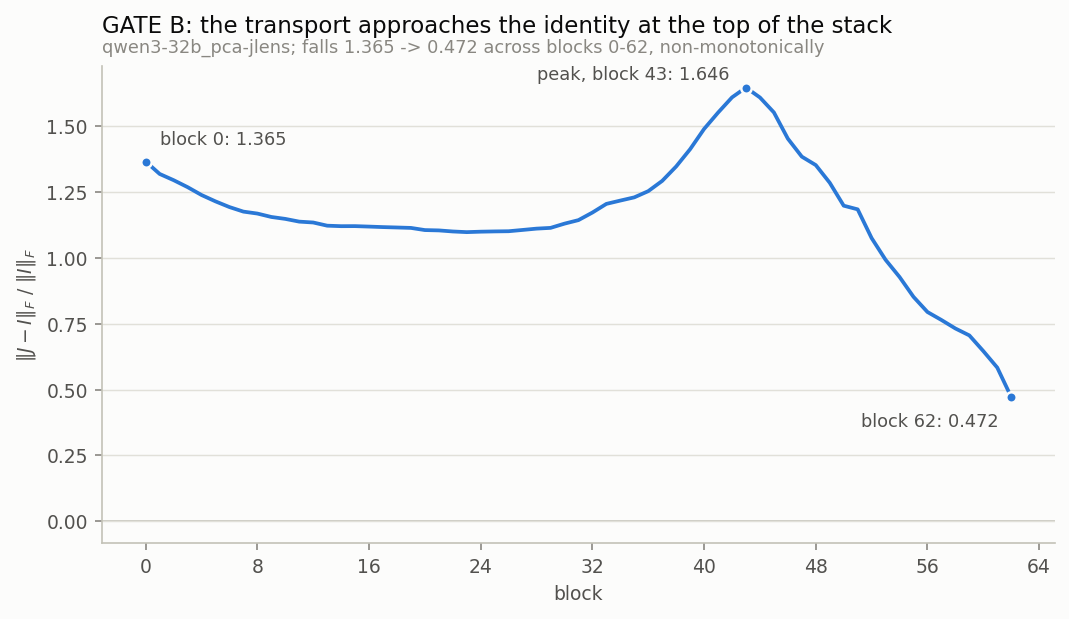

**GATE B -- agreement at block 62 (probe: `basketball-players`)**

,comparison,value
0,top-1 J-lens == model output,1 / 1
1,top-1 J-lens == logit lens,1 / 1
2,"top-12 overlap, J-lens vs model",10 / 12
3,"top-12 overlap, J-lens vs logit lens",8 / 12


**Reading.** The distance falls from **1.365** at block 0 to **0.472** at block 62, which is the expected direction — the highest fitted block transports across one residual block, so `J` should be near identity. The fall is **not monotone**: it rises to **1.646** at block 43 before descending. The gate only records `falls_with_depth` as an endpoint comparison, so the mid-stack hump is visible in the figure and nowhere in the JSON.

At the top block the J-lens agrees with the model on the top-1 token and with the plain logit lens on the top-1 token, and overlaps them on 10/12 and 8/12 of the top-12. GATE B passes.

**Caveat carried forward:** the y-axis of this figure is magnitude-sensitive and the lens divisor is unconfirmed (section 0). The *shape* of the curve is scale-free; the absolute values are scaled by an unknown constant if `n_done` is wrong.

In [5]:
display(Markdown("### 1. Phase 0 -- GATE B"))

with guard("Phase 0 GATE B"):
    p0 = jload("16", "phase0_gate.json")
    if p0 is None:
        emit("> Phase 0 produced no artefact; GATE B cannot be shown.")
    else:
        gb = p0["gate_b"]
        dist = {int(k): float(v) for k, v in gb["identity_distances"].items()}
        blocks = sorted(dist)
        vals = np.array([dist[b] for b in blocks])
        lo, hi = dist[blocks[0]], dist[blocks[-1]]
        peak_i = int(np.argmax(vals))

        fig, ax = plt.subplots()
        ax.plot(blocks, vals, color=plotting.SERIES[0], linewidth=1.8)
        for x, y, text, (dx, dy), ha in [
            (blocks[0], lo, f"block {blocks[0]}: {lo:.3f}", (7, 8), "left"),
            (blocks[peak_i], vals[peak_i],
             f"peak, block {blocks[peak_i]}: {vals[peak_i]:.3f}", (-8, 4), "right"),
            (blocks[-1], hi, f"block {blocks[-1]}: {hi:.3f}", (-6, -14), "right"),
        ]:
            ax.plot([x], [y], marker="o", color=plotting.SERIES[0], markersize=5,
                    markeredgecolor=plotting.SURFACE, markeredgewidth=1.2, zorder=5)
            ax.annotate(text, xy=(x, y), xytext=(dx, dy), textcoords="offset points",
                        fontsize=8.5, color=plotting.INK_SECONDARY, ha=ha)
        ax.axhline(0.0, color=plotting.BASELINE, linewidth=0.8, zorder=0)
        plotting.finish(
            fig, ax,
            "GATE B: the transport approaches the identity at the top of the stack",
            "block", r"$\|J - I\|_F\ /\ \|I\|_F$",
            subtitle=(f"qwen3-32b_pca-jlens; falls {lo:.3f} -> {hi:.3f} across blocks "
                      f"{blocks[0]}-{blocks[-1]}, non-monotonically"),
            integer_x=True,
        )
        emit_fig(fig, "phase0_gate_b_identity.png",
                 "GATE B: ||J - I||_F / ||I||_F against block (16-emotion run)")

        ag = gb["agreement"]
        agree_tbl = pd.DataFrame([
            {"comparison": "top-1 J-lens == model output", "value": f"{ag['top1_jlens_equals_model']} / 1"},
            {"comparison": "top-1 J-lens == logit lens", "value": f"{ag['top1_jlens_equals_logitlens']} / 1"},
            {"comparison": "top-12 overlap, J-lens vs model", "value": f"{ag['top12_overlap_jlens_model']} / 12"},
            {"comparison": "top-12 overlap, J-lens vs logit lens", "value": f"{ag['top12_overlap_jlens_logitlens']} / 12"},
        ])
        emit_table(agree_tbl, f"GATE B -- agreement at block {gb['top_block']} (probe: `{gb['probe']}`)")

        emit(
            f"**Reading.** The distance falls from **{lo:.3f}** at block {blocks[0]} to "
            f"**{hi:.3f}** at block {blocks[-1]}, which is the expected direction — the highest "
            f"fitted block transports across one residual block, so `J` should be near identity. "
            f"The fall is **not monotone**: it rises to **{vals[peak_i]:.3f}** at block "
            f"{blocks[peak_i]} before descending. The gate only records `falls_with_depth` as an "
            f"endpoint comparison, so the mid-stack hump is visible in the figure and nowhere in "
            f"the JSON.\n\n"
            f"At the top block the J-lens agrees with the model on the top-1 token and with the "
            f"plain logit lens on the top-1 token, and overlaps them on "
            f"{ag['top12_overlap_jlens_model']}/12 and {ag['top12_overlap_jlens_logitlens']}/12 of "
            f"the top-12. GATE B passes.\n\n"
            f"**Caveat carried forward:** the y-axis of this figure is magnitude-sensitive and the "
            f"lens divisor is unconfirmed (section 0). The *shape* of the curve is scale-free; the "
            f"absolute values are scaled by an unknown constant if `n_done` is wrong."
        )

---

## 2. Phase 1 — stimuli

The design question for both runs: does every emotion see the *same* topics, so that
a difference between two emotion vectors cannot be a difference between the topics
their stories happened to be about? And is any story short enough that the
`token_offset = 50` prefix skip would leave fewer than `min_pooled_tokens = 10`
tokens to pool over?

In [6]:
emit("## 2. Phase 1 -- stimuli", show=False)
display(Markdown("### 2. Phase 1 -- coverage, topic matching, length"))

P1 = {}
with guard("Phase 1 coverage"):
    quad_rows, meta_rows = {}, {}
    for key in RUN_KEYS:
        p1 = jload(key, "phase1_gate.json")
        if p1 is None:
            continue
        P1[key] = p1
        ds, tm, lf, es = p1["dataset"], p1["topic_matching"], p1["length_fit"], p1["emotion_set"]
        quad_rows[key] = ds["per_quadrant_counts"]
        per_emo = ds["per_emotion_counts"]
        emo_only = {k: v for k, v in per_emo.items() if k != "neutral"}
        meta_rows[key] = {
            "emotions in run": es["n_emotions"],
            "labelled anchors": es["n_anchors"],
            "anchor design": es["anchor_design"],
            "stimulus rows": ds["n_rows"],
            "emotional / neutral": f"{ds['n_emotional']} / {ds['n_neutral']}",
            "stories per emotion (min..max)": (
                f"{min(emo_only.values())}..{max(emo_only.values())}" if emo_only else "--"
            ),
            "distinct story counts": len(set(emo_only.values())),
            "neutral stories": per_emo.get("neutral"),
            "topics total": tm["n_topics_total"],
            "all emotions share topics": tm["all_emotions_same_topics"],
            "topics exactly matched": tm["exactly_matched"],
            "stories per (emotion, topic) cell": ", ".join(str(c) for c in tm["distinct_per_cell_counts"]),
            "split train/val/test": "/".join(
                str(ds["per_split_counts"].get(s)) for s in ("train", "validation", "test")
            ),
            "words min / median / max": f"{lf['words_min']} / {lf['words_median']:.0f} / {lf['words_max']}",
            "approx pooled tokens, min": round(lf["approx_pooled_min"], 1),
            "tokens needed (offset + min pooled)": lf["tokens_needed"],
            "stimuli at length risk": lf["n_at_risk"],
            "warnings": len(es.get("warnings", [])) or "none",
        }

    if meta_rows:
        meta = pd.DataFrame(meta_rows)
        meta.index.name = "field"
        emit_table(meta.reset_index(), "Phase 1 -- stimulus design, both runs")

    if quad_rows:
        quad = pd.DataFrame(quad_rows).fillna(0).astype(int)
        quad.index.name = "quadrant"
        quad = quad.loc[[q for q in ["HA-P", "HA-N", "LA-P", "LA-N", "neutral", "unlabelled"]
                         if q in quad.index]]
        emit_table(quad.reset_index(), "Phase 1 -- stimulus count by circumplex quadrant")

### 2. Phase 1 -- coverage, topic matching, length

**Phase 1 -- stimulus design, both runs**

,field,16,171
0,emotions in run,16,171
1,labelled anchors,16,16
2,anchor design,False,True
3,stimulus rows,6800,34600
4,emotional / neutral,6400 / 400,34200 / 400
5,stories per emotion (min..max),400..400,200..200
6,distinct story counts,1,1
7,neutral stories,400,400
8,topics total,100,100
9,all emotions share topics,True,True


**Phase 1 -- stimulus count by circumplex quadrant**

,quadrant,16,171
0,HA-P,1600,800
1,HA-N,1600,800
2,LA-P,1600,800
3,LA-N,1600,800
4,neutral,400,400
5,unlabelled,0,31000


*Figure -- Phase 1: stimuli per circumplex quadrant, both runs (grey = neutral / unlabelled)*

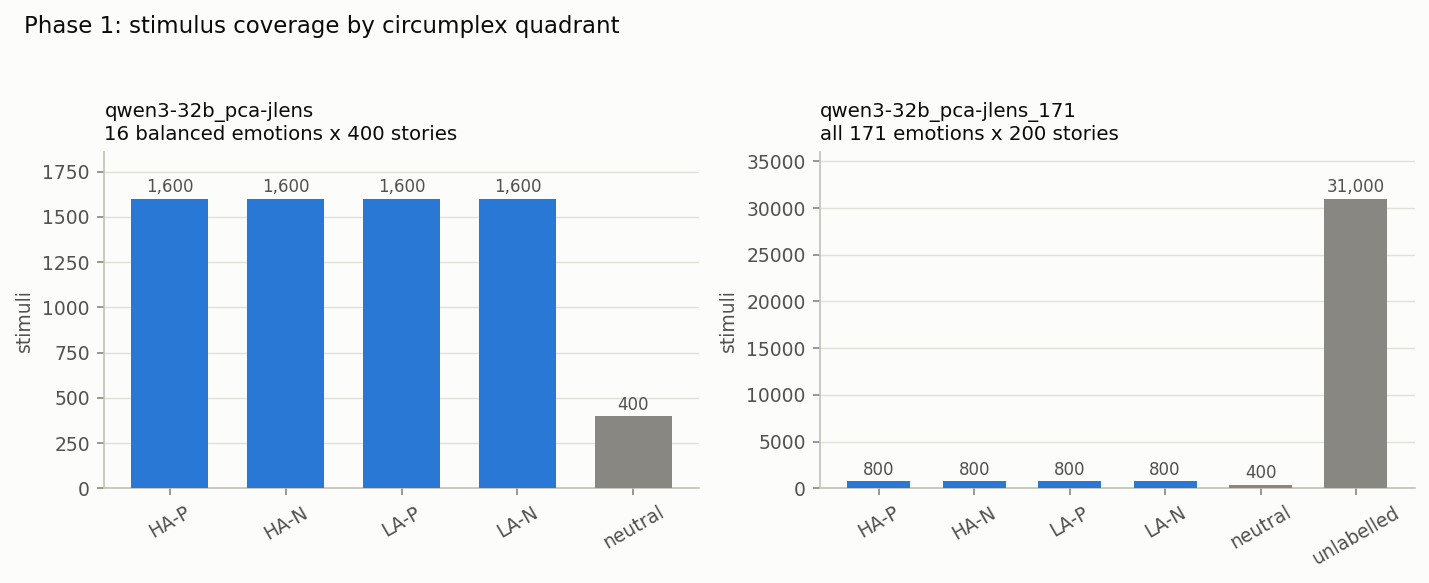

**Reading.**

* **qwen3-32b_pca-jlens** -- 6,800 rows, 16 emotions x 400 stories (+400 neutral). All 100 topics appear for every emotion (`all_emotions_same_topics = True`, `exactly_matched = True`), 4 stories per (emotion, topic) cell. Shortest story pools over ~90 tokens against the 60 needed -- **0 stimuli at length risk**.
* **qwen3-32b_pca-jlens_171** -- 34,600 rows, 171 emotions x 200 stories (+400 neutral). All 100 topics appear for every emotion (`all_emotions_same_topics = True`, `exactly_matched = True`), 2 stories per (emotion, topic) cell. Shortest story pools over ~76 tokens against the 60 needed -- **0 stimuli at length risk**.

Topic matching is exact in both runs, so a difference between two emotion vectors is not a difference in what the stories were about. No stimulus is short enough for the 50-token prefix skip to starve the pool. The 171 run's `unlabelled` quadrant is the 155 emotions with no a-priori circumplex coordinates -- they enter the PCA but cannot enter any alignment or AUROC test, which is why every axis measurement in sections 4 and 5 rests on the same 16 anchors in both runs.

In [7]:
with guard("Phase 1 coverage figure"):
    if not P1:
        emit("> No Phase 1 artefacts; coverage figure skipped.")
    else:
        order = ["HA-P", "HA-N", "LA-P", "LA-N", "neutral", "unlabelled"]
        fig, axes = plt.subplots(1, len(P1), figsize=(9.6, 3.9))
        axes = np.atleast_1d(axes)
        for ax, key in zip(axes, [k for k in RUN_KEYS if k in P1]):
            counts = P1[key]["dataset"]["per_quadrant_counts"]
            labels = [q for q in order if q in counts]
            values = [counts[q] for q in labels]
            colours = [plotting.SERIES[0] if q not in ("neutral", "unlabelled")
                       else plotting.INK_MUTED for q in labels]
            ax.set_axisbelow(True)
            bars = ax.bar(labels, values, color=colours, width=0.66, zorder=3)
            for bar, value in zip(bars, values):
                ax.annotate(f"{value:,}", xy=(bar.get_x() + bar.get_width() / 2, value),
                            xytext=(0, 3), textcoords="offset points", ha="center",
                            fontsize=8, color=plotting.INK_SECONDARY)
            ax.set_title(f"{RUNS[key]}\n{DESIGN[key]}", loc="left", fontsize=9.5,
                         color=plotting.INK_PRIMARY)
            ax.set_ylabel("stimuli")
            ax.tick_params(axis="x", rotation=30)
            ax.margins(y=0.16)
        fig.suptitle("Phase 1: stimulus coverage by circumplex quadrant", x=0.02, ha="left",
                     fontsize=11, color=plotting.INK_PRIMARY)
        fig.tight_layout(rect=(0, 0, 1, 0.94))
        emit_fig(fig, "phase1_quadrant_coverage.png",
                 "Phase 1: stimuli per circumplex quadrant, both runs "
                 "(grey = neutral / unlabelled)")

with guard("Phase 1 reading"):
    if P1:
        bits = []
        for key in RUN_KEYS:
            if key not in P1:
                continue
            tm, lf, ds = P1[key]["topic_matching"], P1[key]["length_fit"], P1[key]["dataset"]
            per_emo = {k: v for k, v in ds["per_emotion_counts"].items() if k != "neutral"}
            bits.append(
                f"* **{RUNS[key]}** -- {ds['n_rows']:,} rows, "
                f"{len(per_emo)} emotions x {sorted(set(per_emo.values()))[0]} stories "
                f"(+{ds['per_emotion_counts'].get('neutral', 0)} neutral). "
                f"All {tm['n_topics_total']} topics appear for every emotion "
                f"(`all_emotions_same_topics = {tm['all_emotions_same_topics']}`, "
                f"`exactly_matched = {tm['exactly_matched']}`), "
                f"{'/'.join(str(c) for c in tm['distinct_per_cell_counts'])} stories per "
                f"(emotion, topic) cell. Shortest story pools over "
                f"~{lf['approx_pooled_min']:.0f} tokens against the {lf['tokens_needed']} "
                f"needed -- **{lf['n_at_risk']} stimuli at length risk**."
            )
        emit(
            "**Reading.**\n\n" + "\n".join(bits) + "\n\n"
            "Topic matching is exact in both runs, so a difference between two emotion vectors "
            "is not a difference in what the stories were about. No stimulus is short enough for "
            "the 50-token prefix skip to starve the pool. The 171 run's `unlabelled` quadrant is "
            "the 155 emotions with no a-priori circumplex coordinates -- they enter the PCA but "
            "cannot enter any alignment or AUROC test, which is why every axis measurement in "
            "sections 4 and 5 rests on the same 16 anchors in both runs."
        )

---

## 3. Phase 2 — emotion vectors and split-half reliability

Each emotion vector is the mean pooled activation at block 31 over that emotion's
stories, minus the grand mean over emotions. Reliability is measured by splitting the
100 topics into two halves of 50, building the vector twice, and taking the cosine
between the halves. **Centred** cosine is the number that matters: the raw cosine is
inflated by the shared component every mean activation has.

In [8]:
emit("## 3. Phase 2 -- split-half reliability", show=False)
display(Markdown("### 3. Phase 2 -- split-half reliability"))

SH = {}
with guard("Phase 2 split-half"):
    stat_rows = {}
    for key in RUN_KEYS:
        frame = cload(key, "phase2_split_half.csv")
        p2 = jload(key, "phase2_gate.json")
        if frame is None:
            continue
        SH[key] = frame
        summ = ((p2 or {}).get("split_half", {}) or {}).get("summary", {})
        emo = frame[frame["emotion"] != "neutral"]
        threshold = ((p2 or {}).get("split_half", {}) or {}).get("threshold", 0.9)
        below = emo[emo["cosine_centered"] < threshold]
        stat_rows[key] = {
            "emotions scored": int(summ.get("n_scored", len(frame))),
            "threshold": threshold,
            "mean centred cosine": summ.get("mean_cosine_centered", float(emo["cosine_centered"].mean())),
            "median centred cosine": summ.get("median_cosine_centered", float(emo["cosine_centered"].median())),
            "min centred cosine": summ.get("min_cosine_centered", float(emo["cosine_centered"].min())),
            "mean RAW cosine (inflated)": summ.get("mean_cosine_raw"),
            "n below threshold": int(len(below)),
            "frac below threshold": len(below) / max(len(emo), 1),
            "weakest 5": ", ".join(
                summ.get("worst") or emo.nsmallest(5, "cosine_centered")["emotion"].tolist()
            ),
            "topics per half": f"{((p2 or {}).get('split_half', {}) or {}).get('n_topics_half_a', '?')}"
                               f" / {((p2 or {}).get('split_half', {}) or {}).get('n_topics_half_b', '?')}",
        }
    if stat_rows:
        stats = pd.DataFrame(stat_rows)
        stats.index.name = "field"
        emit_table(stats.reset_index(), "Phase 2 -- split-half reliability summary, both runs")

### 3. Phase 2 -- split-half reliability

**Phase 2 -- split-half reliability summary, both runs**

,field,16,171
0,emotions scored,17,172
1,threshold,0.9,0.9
2,mean centred cosine,0.966205,0.938273
3,median centred cosine,0.964314,0.943748
4,min centred cosine,0.9535,0.822067
5,mean RAW cosine (inflated),0.998447,0.997777
6,n below threshold,0,11
7,frac below threshold,0.0,0.064327
8,weakest 5,"sad, gloomy, weary, anxious, bored","hurt, troubled, astonished, worried, relieved"
9,topics per half,50 / 50,50 / 50


/var/folders/43/_0d5jq894wvgs7d31w0ccq980000gn/T/ipykernel_75125/3681012192.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.96))


*Figure -- Phase 2: per-emotion split-half centred cosine, sorted ascending, 0.9 threshold dashed (red bars fall below it). Note the y-axis is truncated near 0.78 so the threshold is resolvable*

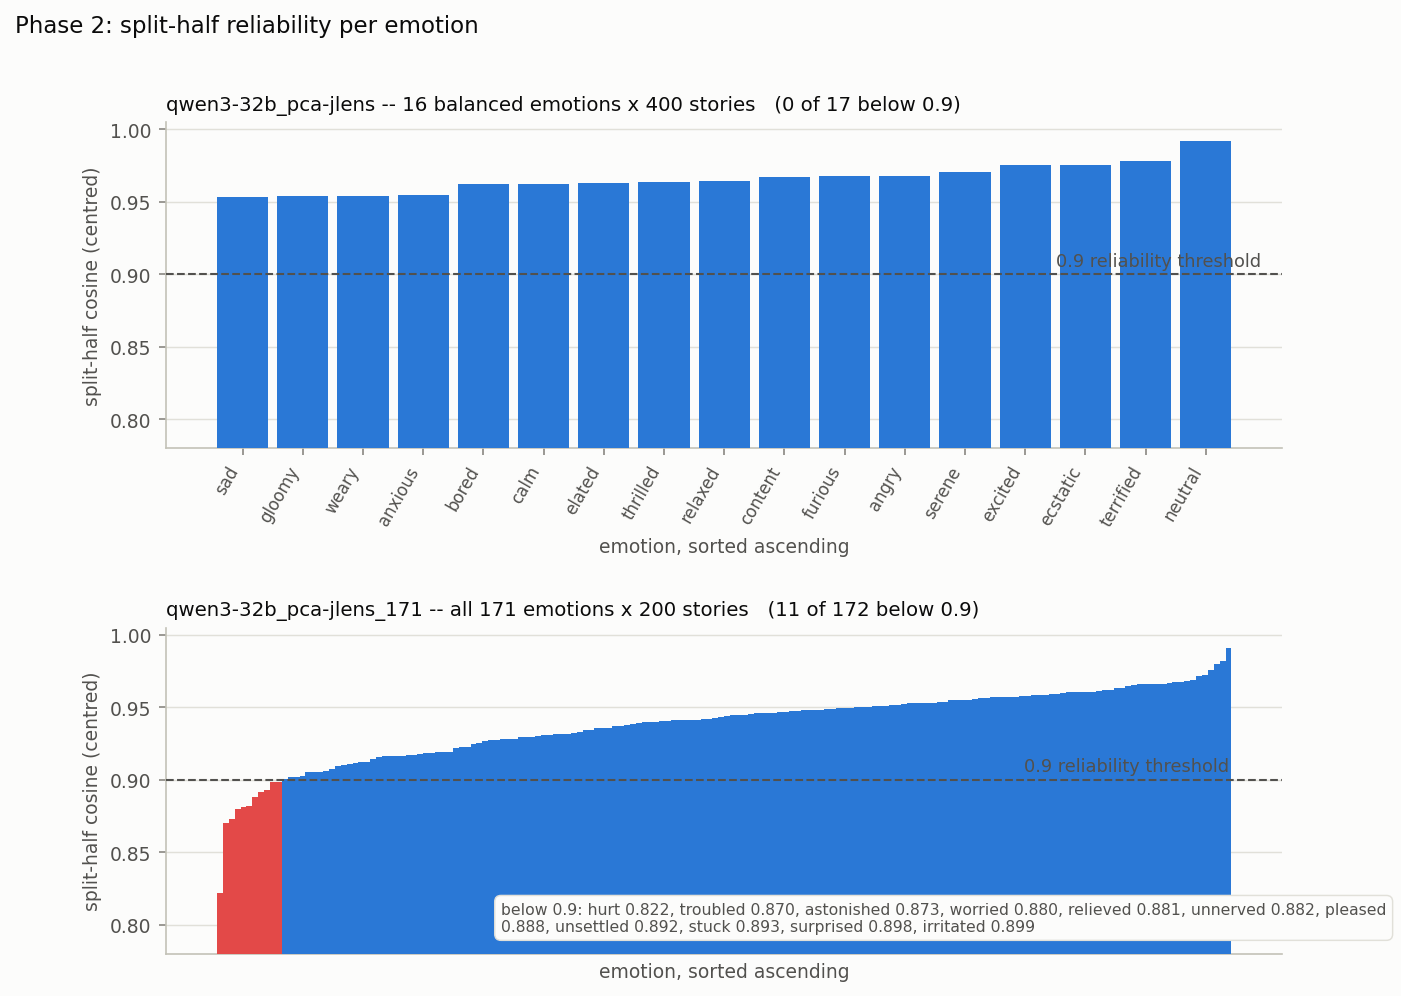

In [9]:
with guard("Phase 2 split-half figure"):
    keys = [k for k in RUN_KEYS if k in SH]
    if not keys:
        emit("> No split-half CSVs; figure skipped.")
    else:
        fig, axes = plt.subplots(
            len(keys), 1, figsize=(9.6, 3.6 * len(keys)),
            gridspec_kw={"hspace": 0.55},
        )
        axes = np.atleast_1d(axes)
        for ax, key in zip(axes, keys):
            frame = SH[key].sort_values("cosine_centered").reset_index(drop=True)
            values = frame["cosine_centered"].to_numpy()
            names = frame["emotion"].tolist()
            below = values < 0.9
            colours = [plotting.DIVERGING_HIGH if b else plotting.SERIES[0] for b in below]
            xs = np.arange(len(values))
            ax.set_axisbelow(True)
            ax.bar(xs, values, color=colours, width=0.85 if len(values) < 40 else 1.0,
                   linewidth=0, zorder=3)
            ax.axhline(0.9, color=plotting.INK_SECONDARY, linewidth=1.0, linestyle="--",
                       zorder=4)
            lo = min(0.78, float(values.min()) - 0.03)
            ax.set_ylim(lo, 1.005)
            ax.annotate("0.9 reliability threshold", xy=(len(values) * 0.995, 0.9),
                        xytext=(0, 4), textcoords="offset points", ha="right",
                        fontsize=8.5, color=plotting.INK_SECONDARY, zorder=5)
            if len(values) <= 40:
                ax.set_xticks(xs)
                ax.set_xticklabels(names, rotation=60, ha="right", fontsize=8)
            else:
                # 172 bars are a pixel apart -- per-bar labels would be unreadable, so
                # the ones that matter go in a text block instead.
                ax.set_xticks([])
                listed = ", ".join(
                    f"{n} {v:.3f}" for n, v in zip(names, values) if v < 0.9
                )
                ax.text(
                    0.30, 0.06,
                    "below 0.9: " + (listed or "none"),
                    transform=ax.transAxes, fontsize=7.5, color=plotting.INK_SECONDARY,
                    va="bottom", ha="left", wrap=True,
                    bbox=dict(facecolor=plotting.SURFACE, edgecolor=plotting.GRIDLINE,
                              linewidth=0.7, boxstyle="round,pad=0.4"),
                )
            n_below = int(below.sum())
            ax.set_title(
                f"{RUNS[key]} -- {DESIGN[key]}   "
                f"({n_below} of {len(values)} below 0.9)",
                loc="left", fontsize=9.5, color=plotting.INK_PRIMARY,
            )
            ax.set_ylabel("split-half cosine (centred)")
            ax.set_xlabel("emotion, sorted ascending")
        fig.suptitle("Phase 2: split-half reliability per emotion", x=0.02, ha="left",
                     fontsize=11, color=plotting.INK_PRIMARY)
        fig.tight_layout(rect=(0, 0, 1, 0.96))
        emit_fig(fig, "phase2_split_half.png",
                 "Phase 2: per-emotion split-half centred cosine, sorted ascending, "
                 "0.9 threshold dashed (red bars fall below it). Note the y-axis is "
                 "truncated near 0.78 so the threshold is resolvable")

In [10]:
with guard("Phase 2 reading"):
    if not SH:
        emit("> No split-half data to read.")
    else:
        lines = []
        for key in RUN_KEYS:
            if key not in SH:
                continue
            frame = SH[key]
            emo = frame[frame["emotion"] != "neutral"]
            worst = emo.nsmallest(5, "cosine_centered")
            below = emo[emo["cosine_centered"] < 0.9]
            lines.append(
                f"* **{RUNS[key]}** -- mean {emo['cosine_centered'].mean():.3f}, "
                f"median {emo['cosine_centered'].median():.3f}, "
                f"min {emo['cosine_centered'].min():.3f}. "
                f"{len(below)} of {len(emo)} emotions fall below 0.9. Weakest five: "
                + ", ".join(f"`{r.emotion}` {r.cosine_centered:.3f}"
                            for r in worst.itertuples())
                + "."
            )

        quad_note = ""
        p1 = P1.get("16")
        if p1 is not None and "16" in SH:
            quad_by_emotion = {e["emotion"]: e["quadrant"] for e in p1["emotion_set"]["emotions"]}
            emo16 = SH["16"][SH["16"]["emotion"] != "neutral"]
            worst5 = emo16.nsmallest(5, "cosine_centered")["emotion"].tolist()
            quads = [quad_by_emotion.get(e, "?") for e in worst5]
            n_lan = quads.count("LA-N")
            detail = ", ".join(f"`{e}` ({q})" for e, q in zip(worst5, quads))
            quad_note = (
                f"\n\n**The 16-run's weak tail is one quadrant.** The five weakest are {detail} — "
                f"**{n_lan} of 5 are the low-arousal-negative quadrant** "
                f"(`{'`, `'.join(e for e, q in zip(worst5, quads) if q == 'LA-N')}`), "
                f"the whole of LA-N. Low-arousal negative states (sadness, gloom, boredom, "
                f"weariness) produce the least topic-invariant activation of the four quadrants. "
                f"That is a real asymmetry in the stimulus set or the representation, not noise "
                f"spread evenly across the design."
            )

        emit(
            "**Reading.**\n\n" + "\n".join(lines) + quad_note + "\n\n"
            "The raw (uncentred) cosine is ~0.998 in both runs. Reporting that number would be "
            "meaningless — it measures the shared component of any mean activation, not "
            "emotion-specific signal. Everything above and downstream uses the centred cosine."
        )

**Reading.**

* **qwen3-32b_pca-jlens** -- mean 0.965, median 0.964, min 0.954. 0 of 16 emotions fall below 0.9. Weakest five: `sad` 0.954, `gloomy` 0.954, `weary` 0.954, `anxious` 0.955, `bored` 0.962.
* **qwen3-32b_pca-jlens_171** -- mean 0.938, median 0.943, min 0.822. 11 of 171 emotions fall below 0.9. Weakest five: `hurt` 0.822, `troubled` 0.870, `astonished` 0.873, `worried` 0.880, `relieved` 0.881.

**The 16-run's weak tail is one quadrant.** The five weakest are `sad` (LA-N), `gloomy` (LA-N), `weary` (LA-N), `anxious` (HA-N), `bored` (LA-N) — **4 of 5 are the low-arousal-negative quadrant** (`sad`, `gloomy`, `weary`, `bored`), the whole of LA-N. Low-arousal negative states (sadness, gloom, boredom, weariness) produce the least topic-invariant activation of the four quadrants. That is a real asymmetry in the stimulus set or the representation, not noise spread evenly across the design.

The raw (uncentred) cosine is ~0.998 in both runs. Reporting that number would be meaningless — it measures the shared component of any mean activation, not emotion-specific signal. Everything above and downstream uses the centred cosine.

---

## 4. Phase 3 — PCA over the emotion vectors

The headline claim: PCA over the emotion vectors recovers something like the
valence × arousal circumplex without ever being told about it.

The existing figures show PC1–PC2. For the 171 run that plane is the wrong place to
look — this section adds the PC2–PC3 scatter and measures how much of the a-priori
valence axis actually lives in each plane.

### 4. Phase 3 -- existing figures

*Figure -- qwen3-32b_pca-jlens: emotion vectors in the PC1-PC2 plane*

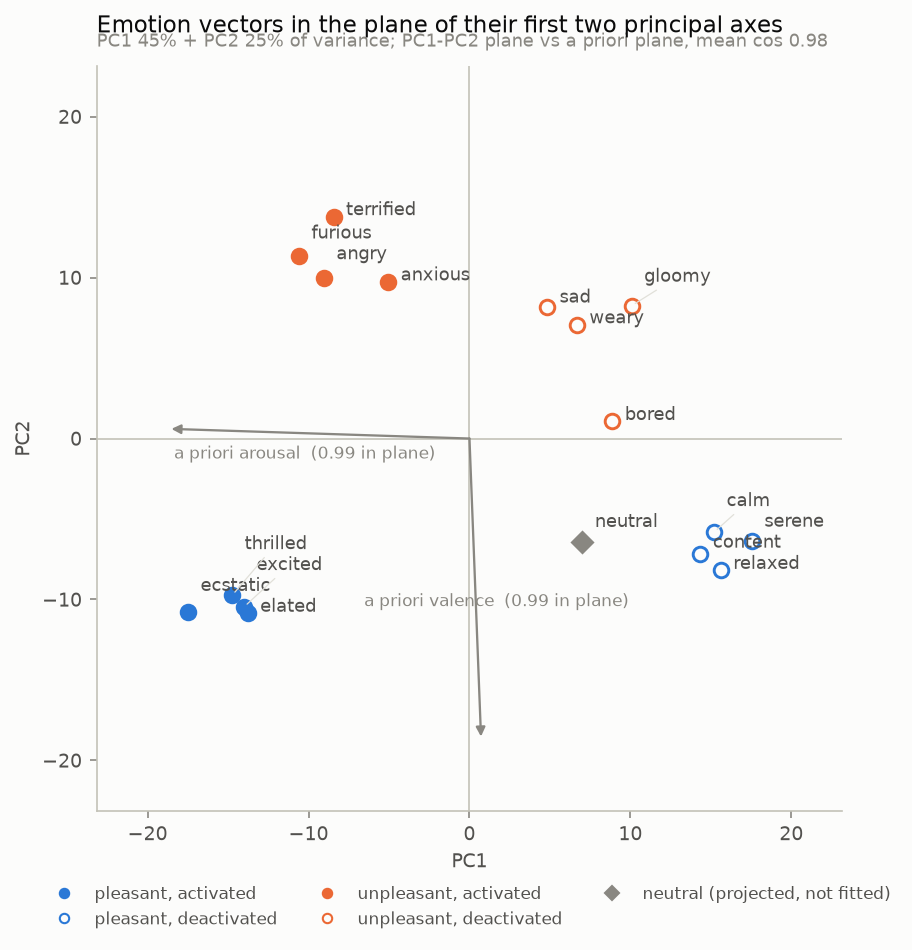

*Figure -- qwen3-32b_pca-jlens: variance explained per PC against the isotropic null*

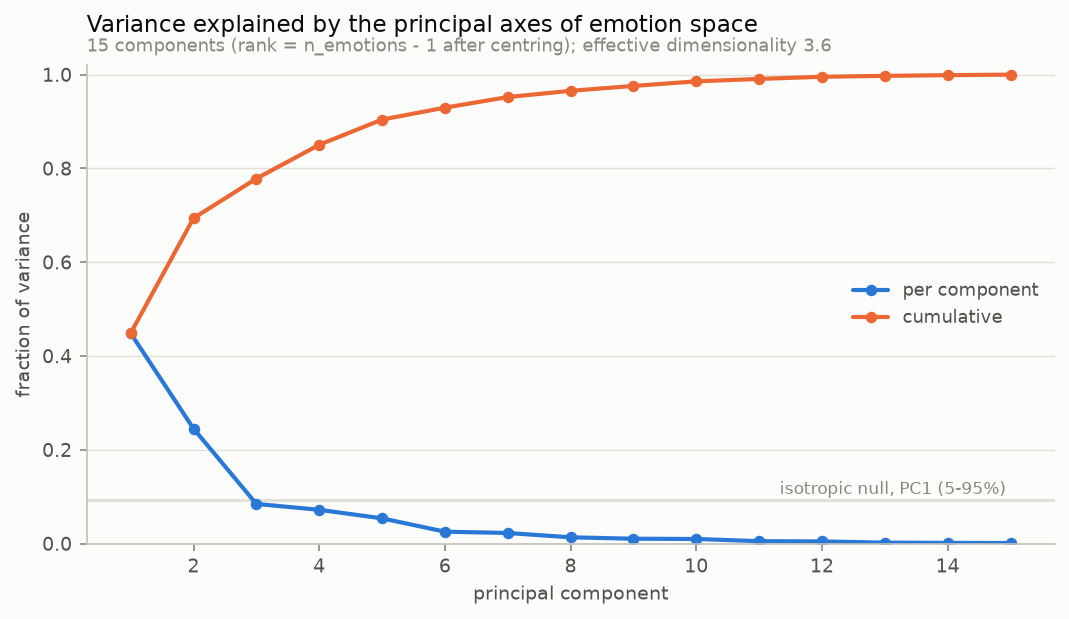

*Figure -- qwen3-32b_pca-jlens: per-PC alignment with the a-priori circumplex axes*

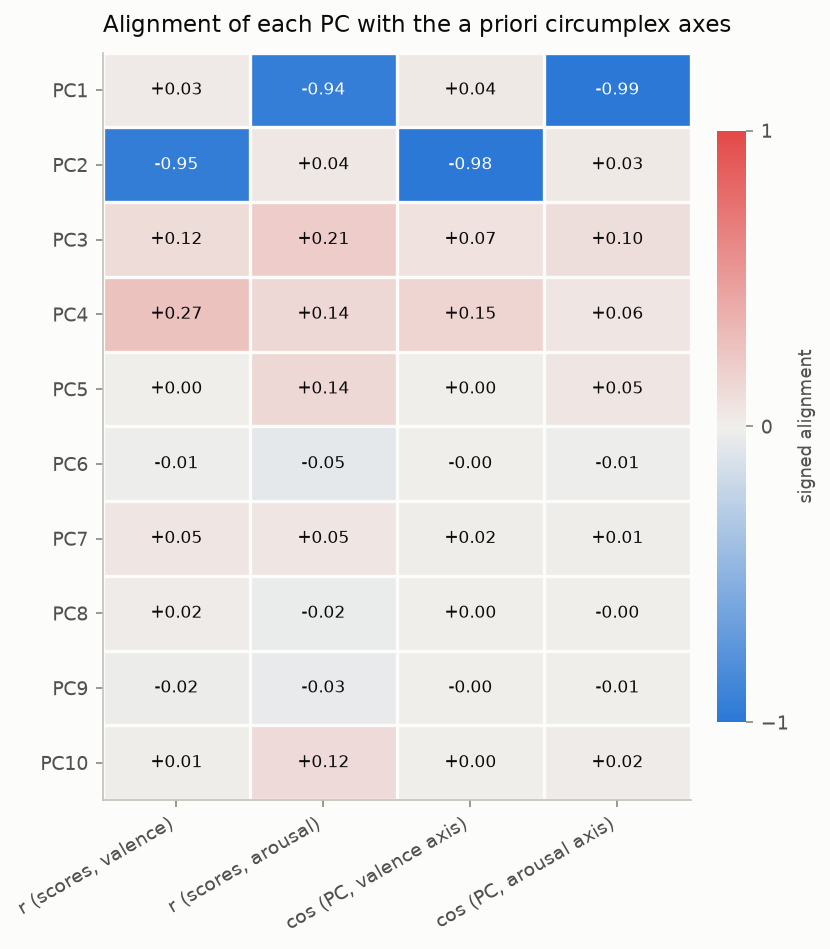

*Figure -- qwen3-32b_pca-jlens_171: emotion vectors in the PC1-PC2 plane*

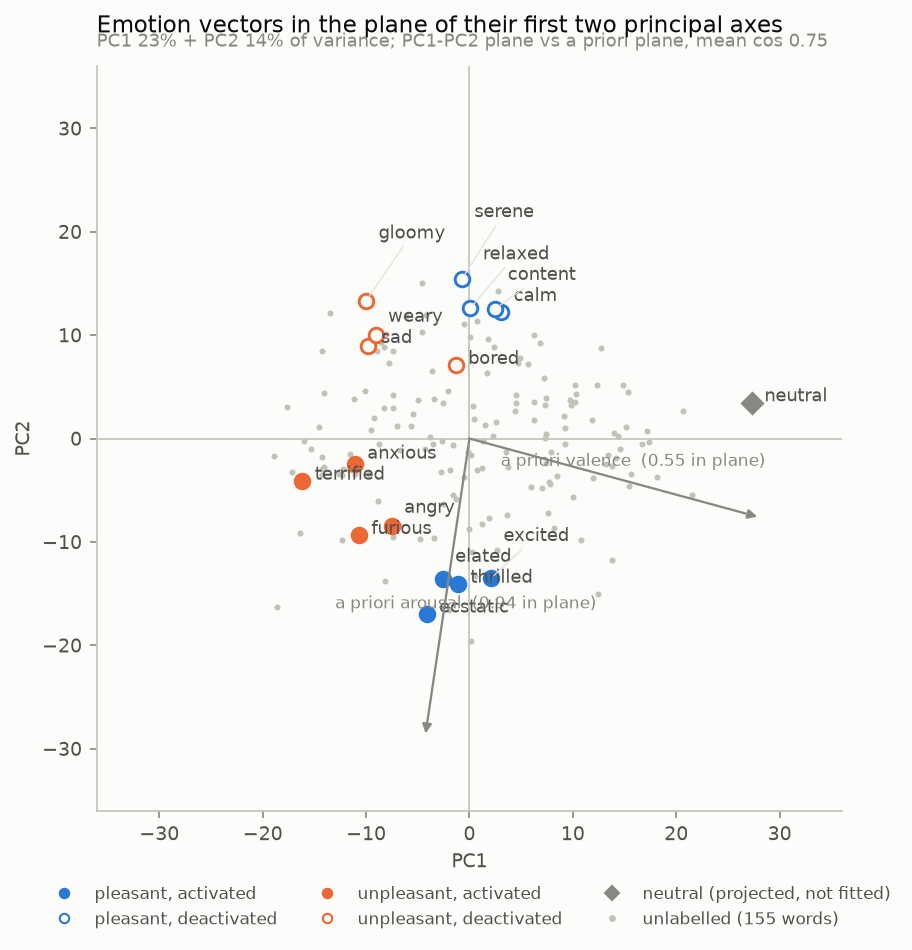

*Figure -- qwen3-32b_pca-jlens_171: variance explained per PC against the isotropic null*

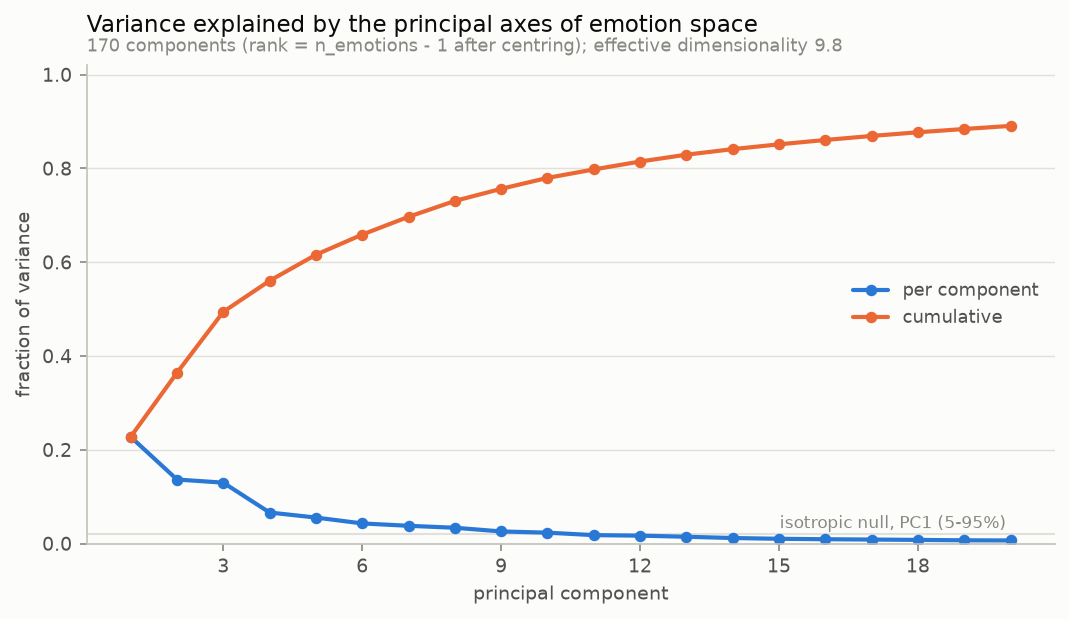

*Figure -- qwen3-32b_pca-jlens_171: per-PC alignment with the a-priori circumplex axes*

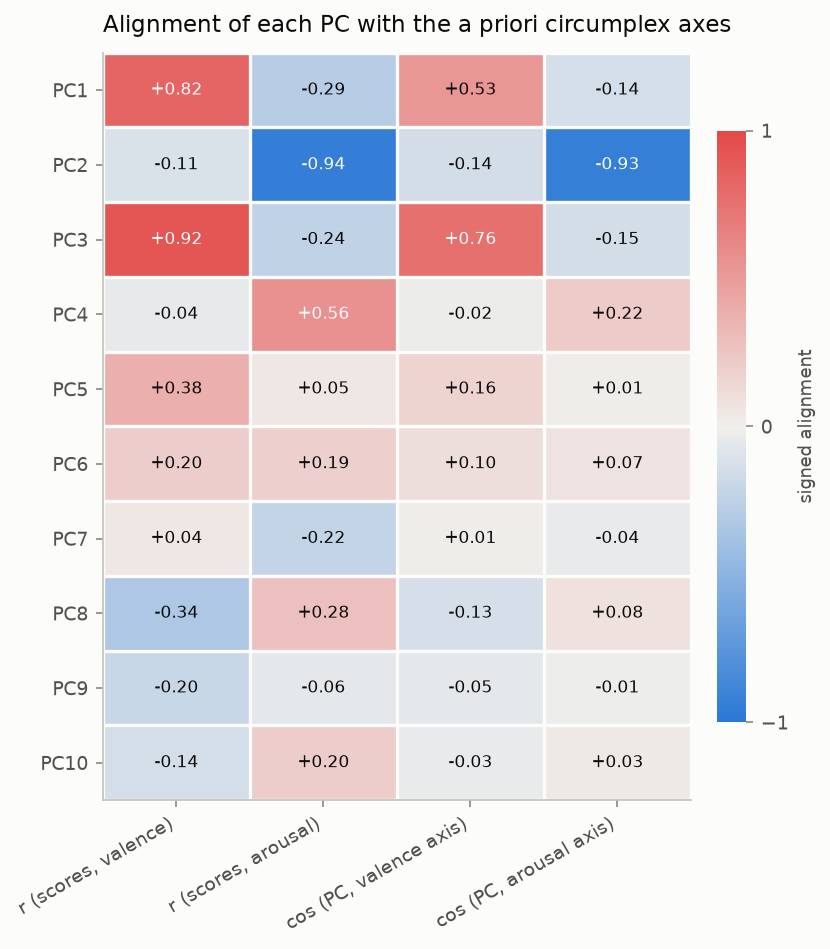

In [11]:
emit("## 4. Phase 3 -- PCA", show=False)
display(Markdown("### 4. Phase 3 -- existing figures"))

for key in RUN_KEYS:
    for fname, what in [
        ("phase3_pc1_pc2_scatter.png", "emotion vectors in the PC1-PC2 plane"),
        ("phase3_variance_explained.png", "variance explained per PC against the isotropic null"),
        ("phase3_alignment.png", "per-PC alignment with the a-priori circumplex axes"),
    ]:
        emit_existing_fig(phases(key) / fname, f"{RUNS[key]}: {what}")

In [12]:
display(Markdown("### 4. Phase 3 -- variance and effective dimensionality"))

VAR, ALIGN, GATE3 = {}, {}, {}
with guard("Phase 3 variance"):
    rows = {}
    for key in RUN_KEYS:
        var = cload(key, "phase3_variance.csv")
        gate = jload(key, "phase3_gate.json")
        if var is None or gate is None:
            continue
        VAR[key], GATE3[key] = var, gate
        pca, stab, nb = gate["pca"], gate["pc_stability"], gate.get("null_band", {})
        ratios = pca["explained_variance_ratio"]
        rows[key] = {
            "emotions in fit": len(gate.get("alignment", {}).get("per_pc", [])) and pca["rank"] + 1,
            "PCA rank": pca["rank"],
            "mean-centred": pca["mean_centered"],
            "neutral in fit": pca["include_neutral_in_pca"],
            "PC1 variance": ratios[0],
            "PC2 variance": ratios[1],
            "PC3 variance": ratios[2],
            "top-2 cumulative": sum(ratios[:2]),
            "top-3 cumulative": sum(ratios[:3]),
            "participation ratio (effective dim)": pca["participation_ratio"],
            "isotropic null, per-PC p50": nb.get("pc1", {}).get("p50"),
            "PC stability: n stable of 10 (cos > 0.8)": stab["n_stable"],
            "PC stability: min cosine": stab["min_cosine"],
            "axes identified": stab["axes_identified"],
            "top-2 plane stable": stab["plane_stable"],
        }
    if rows:
        var_tbl = pd.DataFrame(rows)
        var_tbl.index.name = "field"
        emit_table(var_tbl.reset_index(), "Phase 3 -- variance structure, both runs")

### 4. Phase 3 -- variance and effective dimensionality

**Phase 3 -- variance structure, both runs**

,field,16,171
0,emotions in fit,16,171
1,PCA rank,15,170
2,mean-centred,True,True
3,neutral in fit,False,False
4,PC1 variance,0.44861,0.227613
5,PC2 variance,0.24516,0.136602
6,PC3 variance,0.084554,0.129942
7,top-2 cumulative,0.693771,0.364215
8,top-3 cumulative,0.778324,0.494157
9,participation ratio (effective dim),3.594839,9.793057


In [13]:
display(Markdown("### 4. Phase 3 -- per-PC alignment with valence and arousal"))

with guard("Phase 3 alignment table"):
    frames = []
    for key in RUN_KEYS:
        align = cload(key, "phase3_alignment.csv")
        if align is None:
            continue
        ALIGN[key] = align
        sub = align[["pc", "explained_variance_ratio", "r_valence", "r_arousal",
                     "cos_valence", "cos_arousal"]].copy()
        sub.columns = pd.MultiIndex.from_product([[f"{key} ({DESIGN[key]})"], sub.columns])
        frames.append(sub.set_index(sub.columns[0]))
    if frames:
        joined = pd.concat(frames, axis=1)
        joined.index.name = "PC"
        flat = joined.copy()
        flat.columns = [f"{a.split(' ')[0]}: {b}" for a, b in joined.columns]
        emit_table(flat.reset_index().round(3),
                   "Phase 3 -- per-PC correlation and cosine with the a-priori axes "
                   "(r = correlation of PC scores with the +-1 anchor labels; "
                   "cos = cosine of the PC direction with the fitted axis)")

with guard("Phase 3 axis correspondence"):
    corr_rows = []
    for key in RUN_KEYS:
        if key not in ALIGN:
            continue
        align = ALIGN[key]
        gate = GATE3.get(key, {})
        summ = gate.get("alignment", {}).get("summary", {})
        best_v = int(align.loc[align["r_valence"].abs().idxmax(), "pc"])
        best_a = int(align.loc[align["r_arousal"].abs().idxmax(), "pc"])
        rv = float(align.loc[align["pc"] == best_v, "r_valence"].iloc[0])
        ra = float(align.loc[align["pc"] == best_a, "r_arousal"].iloc[0])
        cf = gate.get("alignment", {}).get("crossfit", {})
        corr_rows.append({
            "run": RUNS[key],
            "design": DESIGN[key],
            "PC carrying valence": f"PC{best_v} (r = {rv:+.2f})",
            "PC carrying arousal": f"PC{best_a} (r = {ra:+.2f})",
            "variance in those two PCs": (
                float(align.loc[align["pc"] == best_v, "explained_variance_ratio"].iloc[0])
                + float(align.loc[align["pc"] == best_a, "explained_variance_ratio"].iloc[0])
            ),
            "PC1-PC2 plane vs a-priori plane, principal cosines": ", ".join(
                f"{c:.2f}" for c in summ.get("plane_cosines", [])
            ),
            "worst plane angle, cross-fit (deg)": cf.get("worst_plane_angle_deg"),
        })
    if corr_rows:
        emit_table(pd.DataFrame(corr_rows),
                   "Phase 3 -- which PC carries which circumplex axis")

### 4. Phase 3 -- per-PC alignment with valence and arousal

**Phase 3 -- per-PC correlation and cosine with the a-priori axes (r = correlation of PC scores with the +-1 anchor labels; cos = cosine of the PC direction with the fitted axis)**

,PC,16: explained_variance_ratio,16: r_valence,16: r_arousal,16: cos_valence,16: cos_arousal,171: explained_variance_ratio,171: r_valence,171: r_arousal,171: cos_valence,171: cos_arousal
0,1,0.449,0.027,-0.944,0.038,-0.992,0.228,0.824,-0.287,0.530,-0.139
1,2,0.245,-0.951,0.041,-0.985,0.032,0.137,-0.110,-0.944,-0.144,-0.935
2,3,0.085,0.117,0.209,0.071,0.095,0.130,0.919,-0.238,0.759,-0.148
3,4,0.072,0.272,0.135,0.153,0.057,0.066,-0.042,0.562,-0.022,0.219
4,5,0.054,0.001,0.139,0.001,0.051,0.056,0.376,0.046,0.161,0.015
5,6,0.025,-0.010,-0.048,-0.003,-0.012,0.043,0.202,0.186,0.098,0.068
6,7,0.023,0.049,0.050,0.015,0.012,0.038,0.039,-0.222,0.009,-0.039
7,8,0.013,0.020,-0.024,0.005,-0.004,0.034,-0.336,0.278,-0.128,0.080
8,9,0.010,-0.023,-0.032,-0.005,-0.005,0.026,-0.199,-0.059,-0.052,-0.012
9,10,0.010,0.009,0.125,0.002,0.019,0.023,-0.139,0.200,-0.032,0.035


**Phase 3 -- which PC carries which circumplex axis**

,run,design,PC carrying valence,PC carrying arousal,variance in those two PCs,"PC1-PC2 plane vs a-priori plane, principal cosines","worst plane angle, cross-fit (deg)"
0,qwen3-32b_pca-jlens,16 balanced emotions x 400 stories,PC2 (r = -0.95),PC1 (r = -0.94),0.693771,"1.00, 0.95",20.206078
1,qwen3-32b_pca-jlens_171,all 171 emotions x 200 stories,PC3 (r = +0.92),PC2 (r = -0.94),0.266544,"0.95, 0.54",62.200600


In [14]:
display(Markdown("### 4. Phase 3 -- how much of the valence axis lives in each plane"))

INPLANE = {}
with guard("Phase 3 in-plane fractions"):
    rows = []
    for key in RUN_KEYS:
        if key not in ALIGN:
            continue
        align = ALIGN[key].set_index("pc")
        def frac(axis, pcs):
            return float(np.sqrt(sum(align.loc[p, f"cos_{axis}"] ** 2 for p in pcs)))
        INPLANE[key] = {
            "valence in PC1-PC2": frac("valence", [1, 2]),
            "valence in PC2-PC3": frac("valence", [2, 3]),
            "valence in PC1-PC3": frac("valence", [1, 2, 3]),
            "arousal in PC1-PC2": frac("arousal", [1, 2]),
            "arousal in PC2-PC3": frac("arousal", [2, 3]),
            "arousal in PC1-PC3": frac("arousal", [1, 2, 3]),
        }
        rows.append({"run": RUNS[key], **{k: round(v, 3) for k, v in INPLANE[key].items()}})
    if rows:
        emit_table(pd.DataFrame(rows),
                   "Phase 3 -- norm of the unit a-priori axis captured by each PC subspace "
                   "(1.0 = the axis lies entirely inside that subspace)")
        if "171" in INPLANE:
            v12 = INPLANE["171"]["valence in PC1-PC2"]
            v23 = INPLANE["171"]["valence in PC2-PC3"]
            v123 = INPLANE["171"]["valence in PC1-PC3"]
            emit(
                f"**This is why the existing PC1-PC2 figure understates the 171 run.** Only "
                f"**{v12:.0%}** of the valence axis lies in the PC1-PC2 plane. Moving to PC2-PC3 "
                f"raises it to **{v23:.0%}**, and the first three PCs together hold **{v123:.0%}**. "
                f"PC3 carries the valence signal the published scatter cannot show."
            )

### 4. Phase 3 -- how much of the valence axis lives in each plane

**Phase 3 -- norm of the unit a-priori axis captured by each PC subspace (1.0 = the axis lies entirely inside that subspace)**

,run,valence in PC1-PC2,valence in PC2-PC3,valence in PC1-PC3,arousal in PC1-PC2,arousal in PC2-PC3,arousal in PC1-PC3
0,qwen3-32b_pca-jlens,0.986,0.987,0.988,0.992,0.100,0.997
1,qwen3-32b_pca-jlens_171,0.549,0.772,0.937,0.945,0.946,0.956


**This is why the existing PC1-PC2 figure understates the 171 run.** Only **55%** of the valence axis lies in the PC1-PC2 plane. Moving to PC2-PC3 raises it to **77%**, and the first three PCs together hold **94%**. PC3 carries the valence signal the published scatter cannot show.

### 4. Phase 3 -- PC2 vs PC3 for the 171-emotion run (new figure)

*Figure -- Phase 3 (new): the 171-emotion run in the PC2-PC3 plane, with the 16 labelled anchors highlighted and the a-priori axes projected into the plane*

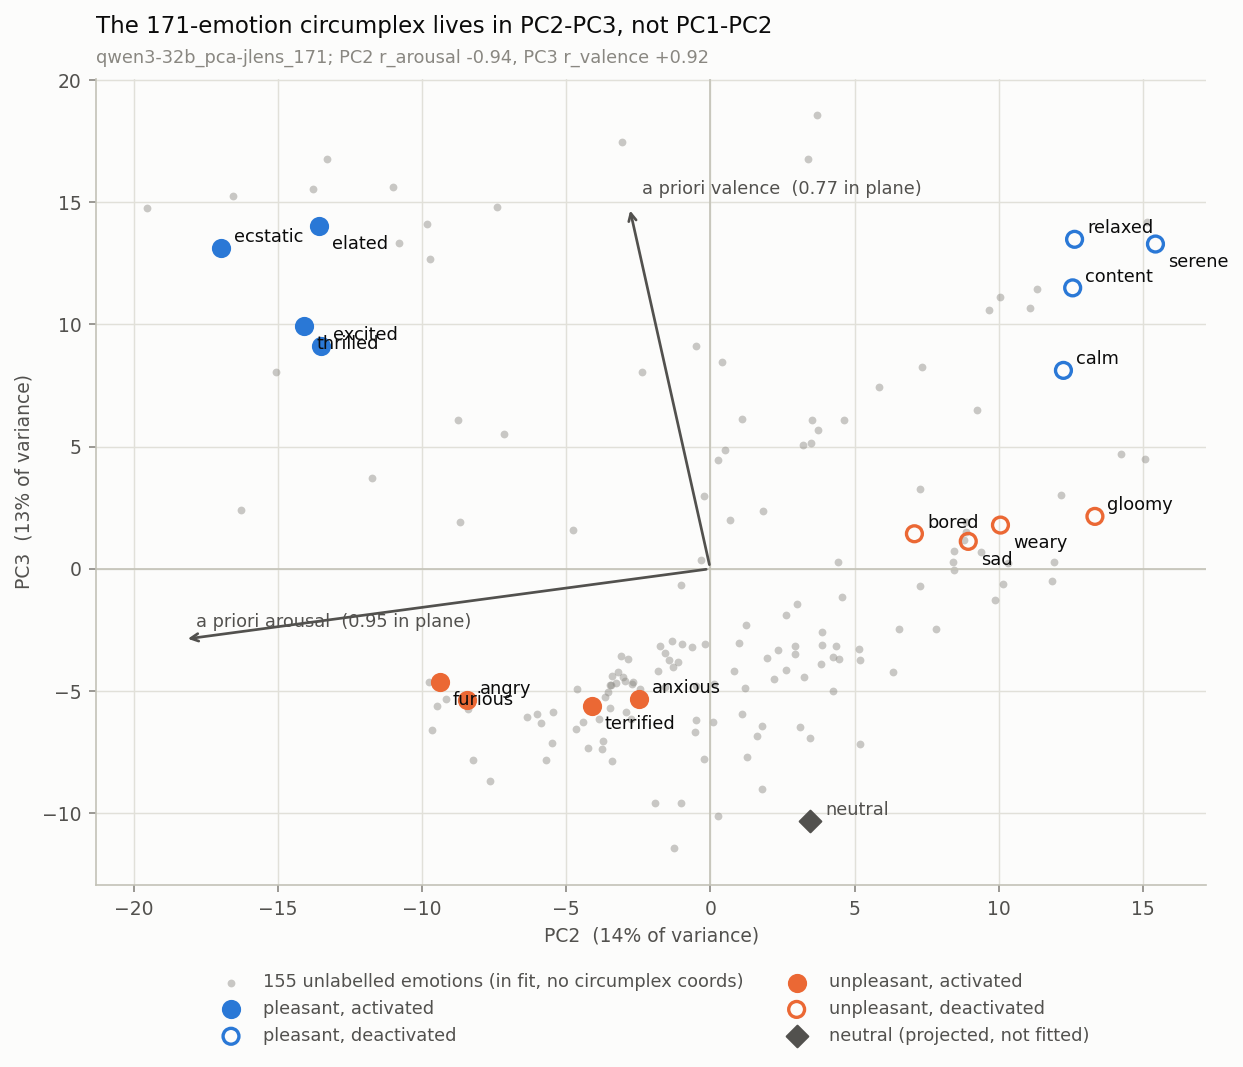

In [15]:
display(Markdown("### 4. Phase 3 -- PC2 vs PC3 for the 171-emotion run (new figure)"))

with guard("Phase 3 PC2-PC3 scatter"):
    scores = cload("171", "phase3_scores.csv")
    align = ALIGN.get("171")
    var = VAR.get("171")
    if scores is None or align is None:
        emit("> Phase 3 scores or alignment missing for the 171 run; scatter skipped.")
    else:
        a = align.set_index("pc")
        xr = float(a.loc[2, "explained_variance_ratio"])
        yr = float(a.loc[3, "explained_variance_ratio"])

        anchors = scores[scores["is_anchor"] == True]  # noqa: E712 -- pandas mask
        others = scores[(scores["is_anchor"] != True) & (scores["in_pca_fit"] == True)]  # noqa: E712
        neutral = scores[scores["emotion"] == "neutral"]

        # Anchors sit close together; nudge colliding labels apart rather than
        # letting two emotion names print on top of each other.
        xspan = float(scores["pc2"].max() - scores["pc2"].min())
        yspan = float(scores["pc3"].max() - scores["pc3"].min())
        _placed = []

        def label_offset(x, y):
            for px, py in _placed:
                if abs(x - px) < 0.10 * xspan and abs(y - py) < 0.035 * yspan:
                    _placed.append((x, y))
                    return (6, -11)
            _placed.append((x, y))
            return (6, 3)

        fig, ax = plt.subplots(figsize=(8.4, 7.2))
        ax.grid(True, axis="both", color=plotting.GRIDLINE, linewidth=0.7)
        ax.set_axisbelow(True)
        ax.axhline(0, color=plotting.BASELINE, linewidth=0.8)
        ax.axvline(0, color=plotting.BASELINE, linewidth=0.8)

        ax.scatter(others["pc2"], others["pc3"], s=14, color=plotting.INK_MUTED,
                   alpha=0.45, linewidths=0,
                   label=f"{len(others)} unlabelled emotions (in fit, no circumplex coords)")

        for (val, aro), (colour, filled, name) in {
            (1.0, 1.0): (plotting.SERIES[0], True, "pleasant, activated"),
            (1.0, -1.0): (plotting.SERIES[0], False, "pleasant, deactivated"),
            (-1.0, 1.0): (plotting.SERIES[1], True, "unpleasant, activated"),
            (-1.0, -1.0): (plotting.SERIES[1], False, "unpleasant, deactivated"),
        }.items():
            sub = anchors[(anchors["valence"] == val) & (anchors["arousal"] == aro)]
            ax.scatter(sub["pc2"], sub["pc3"], s=58,
                       facecolors=colour if filled else "none",
                       edgecolors=colour, linewidths=1.6, label=name, zorder=4)
            for row in sub.itertuples():
                ax.annotate(row.emotion, xy=(row.pc2, row.pc3),
                            xytext=label_offset(row.pc2, row.pc3),
                            textcoords="offset points", fontsize=8.5,
                            color=plotting.INK_PRIMARY, zorder=5)

        if len(neutral):
            n = neutral.iloc[0]
            ax.scatter([n["pc2"]], [n["pc3"]], marker="D", s=54,
                       color=plotting.INK_SECONDARY, zorder=5,
                       label="neutral (projected, not fitted)")
            ax.annotate("neutral", xy=(n["pc2"], n["pc3"]), xytext=(7, 3),
                        textcoords="offset points", fontsize=8.5,
                        color=plotting.INK_SECONDARY)

        # a-priori axes, drawn as their projection into this plane
        span = float(max(abs(scores["pc2"]).max(), abs(scores["pc3"]).max()))
        for axis, label in [("valence", "a priori valence"), ("arousal", "a priori arousal")]:
            dx, dy = float(a.loc[2, f"cos_{axis}"]), float(a.loc[3, f"cos_{axis}"])
            inplane = float(np.hypot(dx, dy))
            ax.annotate(
                "", xy=(dx * span, dy * span), xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=plotting.INK_SECONDARY, linewidth=1.3),
            )
            ax.annotate(f"{label}  ({inplane:.2f} in plane)",
                        xy=(dx * span, dy * span), xytext=(6, 6),
                        textcoords="offset points", fontsize=8.5,
                        color=plotting.INK_SECONDARY)

        ax.set_xlabel(f"PC2  ({xr:.0%} of variance)")
        ax.set_ylabel(f"PC3  ({yr:.0%} of variance)")
        ax.set_title("The 171-emotion circumplex lives in PC2-PC3, not PC1-PC2",
                     loc="left", pad=22)
        ax.text(0.0, 1.015,
                f"qwen3-32b_pca-jlens_171; PC2 r_arousal {float(a.loc[2, 'r_arousal']):+.2f}, "
                f"PC3 r_valence {float(a.loc[3, 'r_valence']):+.2f}",
                transform=ax.transAxes, fontsize=8.5, color=plotting.INK_MUTED,
                ha="left", va="bottom")
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.09), ncol=2, frameon=False)
        fig.tight_layout()
        emit_fig(fig, "phase3_pc2_pc3_scatter_171.png",
                 "Phase 3 (new): the 171-emotion run in the PC2-PC3 plane, with the 16 "
                 "labelled anchors highlighted and the a-priori axes projected into the plane")

In [16]:
display(Markdown("### 4. Phase 3 -- do the two runs find the same axes?"))

XRUN = {}
with guard("cross-run PC correspondence"):
    a = stload(phases("16") / "phase3_pcs.safetensors")
    b = stload(phases("171") / "phase3_pcs.safetensors")
    if a is None or b is None:
        emit("> One of the PC safetensors files is missing; cross-run comparison skipped.")
    else:
        A = a["components"][:5].astype(np.float64)
        B = b["components"][:5].astype(np.float64)
        A /= np.linalg.norm(A, axis=1, keepdims=True)
        B /= np.linalg.norm(B, axis=1, keepdims=True)
        M = np.abs(A @ B.T)
        tbl = pd.DataFrame(
            M.round(3),
            index=[f"16-run PC{i}" for i in range(1, 6)],
            columns=[f"171-run PC{j}" for j in range(1, 6)],
        )
        tbl.index.name = "abs cosine"
        emit_table(tbl.reset_index(),
                   "Phase 3 -- absolute cosine between the two runs' principal axes")
        XRUN = {"match_pc": (np.argmax(M, axis=1) + 1).tolist(),
                "match_cos": M.max(axis=1).round(3).tolist()}

        axis_rows = []
        for name in ("valence_axis", "arousal_axis"):
            if name in a and name in b:
                va, vb = a[name].astype(np.float64), b[name].astype(np.float64)
                axis_rows.append({
                    "a-priori axis": name.replace("_axis", ""),
                    "cosine between the two runs' fitted axes":
                        float(va @ vb / np.linalg.norm(va) / np.linalg.norm(vb)),
                })
        if axis_rows:
            emit_table(pd.DataFrame(axis_rows).round(4),
                       "Phase 3 -- the a-priori axes themselves are the same in both runs "
                       "(both are fitted from the same 16 anchors)")

        best = np.argmax(M, axis=1) + 1
        emit(
            f"**Reading.** The correspondence is direct, not an inference from correlation "
            f"signs: **16-run PC1 matches 171-run PC{best[0]} at |cos| = {M[0].max():.2f}**, and "
            f"**16-run PC2 matches 171-run PC{best[1]} at |cos| = {M[1].max():.2f}**. The "
            f"16-run's arousal axis (its PC1) and valence axis (its PC2) reappear in the 171 run "
            f"one slot lower, displaced by a PC1 that the 16-emotion design never produces.\n\n"
            f"Below PC2 the match degrades ({M[2].max():.2f} for 16-run PC3), which is consistent "
            f"with Phase 3's own stability check: only "
            f"{GATE3.get('16', {}).get('pc_stability', {}).get('n_stable', '?')}/10 and "
            f"{GATE3.get('171', {}).get('pc_stability', {}).get('n_stable', '?')}/10 PCs clear "
            f"the 0.8 split-half stability threshold."
        )

### 4. Phase 3 -- do the two runs find the same axes?

**Phase 3 -- absolute cosine between the two runs' principal axes**

,abs cosine,171-run PC1,171-run PC2,171-run PC3,171-run PC4,171-run PC5
0,16-run PC1,0.146,0.927,0.099,0.205,0.046
1,16-run PC2,0.535,0.183,0.765,0.088,0.110
2,16-run PC3,0.259,0.237,0.175,0.183,0.067
3,16-run PC4,0.215,0.070,0.180,0.649,0.294
4,16-run PC5,0.076,0.047,0.272,0.105,0.744


**Phase 3 -- the a-priori axes themselves are the same in both runs (both are fitted from the same 16 anchors)**

,a-priori axis,cosine between the two runs' fitted axes
0,valence,0.9982
1,arousal,0.9989


**Reading.** The correspondence is direct, not an inference from correlation signs: **16-run PC1 matches 171-run PC2 at |cos| = 0.93**, and **16-run PC2 matches 171-run PC3 at |cos| = 0.76**. The 16-run's arousal axis (its PC1) and valence axis (its PC2) reappear in the 171 run one slot lower, displaced by a PC1 that the 16-emotion design never produces.

Below PC2 the match degrades (0.26 for 16-run PC3), which is consistent with Phase 3's own stability check: only 8/10 and 8/10 PCs clear the 0.8 split-half stability threshold.

In [17]:
display(Markdown("### 4. Phase 3 -- what PC1 of the 171 run actually is"))

PC1_171 = {"lo": ["?"], "hi": ["?"], "min": float("nan"), "max": float("nan"),
           "neutral": float("nan")}
with guard("171 PC1 contamination"):
    scores = cload("171", "phase3_scores.csv")
    if scores is None:
        emit("> Phase 3 scores missing for the 171 run.")
    else:
        fitted = scores[scores["in_pca_fit"] == True]  # noqa: E712
        neutral = scores[scores["emotion"] == "neutral"]
        lo = fitted.nsmallest(8, "pc1")["emotion"].tolist()
        hi = fitted.nlargest(8, "pc1")["emotion"].tolist()
        PC1_171 = {
            "lo": lo, "hi": hi,
            "min": float(fitted["pc1"].min()), "max": float(fitted["pc1"].max()),
            "neutral": float(neutral["pc1"].iloc[0]) if len(neutral) else float("nan"),
        }
        rows = [{
            "quantity": "PC1 range over the 171 fitted emotions",
            "value": f"{fitted['pc1'].min():.1f} .. {fitted['pc1'].max():.1f}",
        }, {
            "quantity": "PC1 score of `neutral` (held OUT of the fit)",
            "value": f"{float(neutral['pc1'].iloc[0]):+.1f}" if len(neutral) else "--",
        }, {
            "quantity": "8 lowest on PC1",
            "value": ", ".join(lo),
        }, {
            "quantity": "8 highest on PC1",
            "value": ", ".join(hi),
        }, {
            "quantity": "corr(PC1 score, vector norm)",
            "value": f"{np.corrcoef(fitted['pc1'], fitted['norm'])[0, 1]:+.2f}",
        }]
        emit_table(pd.DataFrame(rows), "Phase 3 -- diagnosing PC1 of the 171-emotion run")

        outside = (len(neutral) and
                   float(neutral["pc1"].iloc[0]) > float(fitted["pc1"].max()))
        emit(
            "**Reading.** PC1 of the 171 run is not a circumplex axis. Its low end is "
            + ", ".join(f"`{e}`" for e in lo[:5])
            + " — overwhelming, high-intensity affect — and its high end is "
            + ", ".join(f"`{e}`" for e in hi[:5])
            + " — appraisal-like, dispositional or motivational states rather than "
              "acute affect. "
            + (
                f"Decisively: **`neutral`, which was held out of the PCA fit entirely, projects "
                f"to PC1 = {float(neutral['pc1'].iloc[0]):+.1f}, beyond the "
                f"{float(fitted['pc1'].max()):+.1f} maximum of all 171 fitted emotions.** "
                if outside else ""
            )
            + "PC1 is substantially an *affect-presence / intensity* axis: it orders states by "
            "how much acute affect is present, with the absence of affect at the extreme. "
            "It correlates with valence (r = "
            f"{float(ALIGN['171'].set_index('pc').loc[1, 'r_valence']):+.2f}) only because "
            "intense states in this vocabulary skew unpleasant. This is the contamination that "
            "pushes the circumplex down into PC2-PC3 and it is the main reason the 171 run's "
            "plane alignment (mean principal cosine "
            f"{GATE3.get('171', {}).get('alignment', {}).get('summary', {}).get('plane_mean_cosine', float('nan')):.2f}) "
            "is so much worse than the 16 run's "
            f"({GATE3.get('16', {}).get('alignment', {}).get('summary', {}).get('plane_mean_cosine', float('nan')):.2f})."
        )

### 4. Phase 3 -- what PC1 of the 171 run actually is

**Phase 3 -- diagnosing PC1 of the 171-emotion run**

,quantity,value
0,PC1 range over the 171 fitted emotions,-18.9 .. 21.5
1,PC1 score of `neutral` (held OUT of the fit),+27.3
2,8 lowest on PC1,"tormented, hysterical, disoriented, distressed..."
3,8 highest on PC1,"greedy, kind, vindictive, smug, self-confident..."
4,"corr(PC1 score, vector norm)",+0.29


**Reading.** PC1 of the 171 run is not a circumplex axis. Its low end is `tormented`, `hysterical`, `disoriented`, `distressed`, `panicked` — overwhelming, high-intensity affect — and its high end is `greedy`, `kind`, `vindictive`, `smug`, `self-confident` — appraisal-like, dispositional or motivational states rather than acute affect. Decisively: **`neutral`, which was held out of the PCA fit entirely, projects to PC1 = +27.3, beyond the +21.5 maximum of all 171 fitted emotions.** PC1 is substantially an *affect-presence / intensity* axis: it orders states by how much acute affect is present, with the absence of affect at the extreme. It correlates with valence (r = +0.82) only because intense states in this vocabulary skew unpleasant. This is the contamination that pushes the circumplex down into PC2-PC3 and it is the main reason the 171 run's plane alignment (mean principal cosine 0.75) is so much worse than the 16 run's (0.98).

In [18]:
with guard("Phase 3 reading"):
    lines = []
    for key in RUN_KEYS:
        if key not in GATE3:
            continue
        g = GATE3[key]
        pca, stab, summ = g["pca"], g["pc_stability"], g["alignment"]["summary"]
        cf = g["alignment"].get("crossfit", {})
        ratios = pca["explained_variance_ratio"]
        lines.append(
            f"* **{RUNS[key]}** — top-2 PCs hold {sum(ratios[:2]):.0%} of variance against an "
            f"isotropic null of {g['null_band']['analytic_isotropic_top2']:.1%}. "
            f"Participation ratio (effective dimensionality) **{pca['participation_ratio']:.2f}**. "
            f"Best valence PC = PC{summ['best_pc_for_valence']}, best arousal PC = "
            f"PC{summ['best_pc_for_arousal']}. Principal cosines between the PC1-PC2 plane and "
            f"the a-priori plane: {', '.join(f'{c:.2f}' for c in summ['plane_cosines'])} "
            f"(mean {summ['plane_mean_cosine']:.2f}). Cross-fit worst plane angle "
            f"{cf.get('worst_plane_angle_deg', float('nan')):.1f} deg. "
            f"`axes_identified = {stab['axes_identified']}`, "
            f"`plane_stable = {stab['plane_stable']}`."
        )
    emit(
        "**Reading — Phase 3 overall.**\n\n" + "\n".join(lines) + "\n\n"
        "The 16-emotion run recovers the circumplex cleanly and the gate says so. The 171-emotion "
        "run recovers the *same two directions* (the cross-run cosines above) but they are no "
        "longer the top two, they hold far less variance, and Phase 3's own stability check marks "
        "the top-2 plane as **not** stable and the axes as **not** identified. "
        "A participation ratio of "
        f"{GATE3.get('171', {}).get('pca', {}).get('participation_ratio', float('nan')):.1f} "
        "is the honest headline for the 171 run: the circumplex is a 2-D slice of a roughly "
        "10-dimensional space, not a description of it."
    )

**Reading — Phase 3 overall.**

* **qwen3-32b_pca-jlens** — top-2 PCs hold 69% of variance against an isotropic null of 13.3%. Participation ratio (effective dimensionality) **3.59**. Best valence PC = PC2, best arousal PC = PC1. Principal cosines between the PC1-PC2 plane and the a-priori plane: 1.00, 0.95 (mean 0.98). Cross-fit worst plane angle 20.2 deg. `axes_identified = True`, `plane_stable = True`.
* **qwen3-32b_pca-jlens_171** — top-2 PCs hold 36% of variance against an isotropic null of 1.2%. Participation ratio (effective dimensionality) **9.79**. Best valence PC = PC3, best arousal PC = PC2. Principal cosines between the PC1-PC2 plane and the a-priori plane: 0.95, 0.54 (mean 0.75). Cross-fit worst plane angle 62.2 deg. `axes_identified = False`, `plane_stable = False`.

The 16-emotion run recovers the circumplex cleanly and the gate says so. The 171-emotion run recovers the *same two directions* (the cross-run cosines above) but they are no longer the top two, they hold far less variance, and Phase 3's own stability check marks the top-2 plane as **not** stable and the axes as **not** identified. A participation ratio of 9.8 is the honest headline for the 171 run: the circumplex is a 2-D slice of a roughly 10-dimensional space, not a description of it.

---

## 5. Phase 4 — reading the PCs through the lens

Phase 4 is the phase whose artefacts are hardest to read: `phase4_gate.json` is
73 KB / 157 KB and `phase4_readouts.csv` carries 360 / 2,220 token rows. Most of that
bulk is the per-emotion GATE A readout — 12 tokens × 16 or × 171 emotions — which
nobody can read as a listing and which is only informative in aggregate.

This section takes the position that the readable form is three views and one number:

1. **one verdict row per PC** — the decision table, ~5 rows per run;
2. **token panels for the top 3 PCs only**, with the `+` and `−` ends adjacent, so a
   reader can judge whether the two ends are actually antonyms;
3. **AUROC per PC per end as a figure**, because the ordering statistic is the part
   that is comparable across PCs and runs;
4. the 2,052-row GATE A block collapsed to a **script-mix percentage**, which is the
   one thing it can honestly support.

Tokens stay in tables and never in figures — the readouts are largely CJK and
matplotlib's default font renders those as tofu boxes.

In [19]:
emit("## 5. Phase 4 -- lens readouts of the PCs", show=False)
display(Markdown("### 5a. Phase 4 -- verdict per PC"))

P4 = {}
with guard("Phase 4 verdict table"):
    rows = []
    for key in RUN_KEYS:
        p4 = jload(key, "phase4_gate.json")
        if p4 is None:
            continue
        P4[key] = p4
        for pc in p4["gate_b"]["per_pc"]:
            note = (pc.get("notes") or [""])[0]
            if pc.get("lexicalised"):
                verdict = f"reads as {pc['best_axis'].upper()}"
                if pc.get("exploratory"):
                    verdict += " (exploratory)"
            elif note.startswith("MURKY"):
                verdict = "MURKY"
            elif pc.get("significant_uncorrected"):
                verdict = "not interpreted (fails family correction)"
            else:
                verdict = "MURKY"
            rows.append({
                "run": key,
                "PC": int(pc["pc"]),
                "variance": pc["explained_variance_ratio"],
                "verdict": verdict,
                "best axis": pc["best_axis"],
                "AUROC (best end, best axis)": max(
                    pc["auroc_valence"], pc["auroc_valence_minus_end"],
                    pc["auroc_arousal"], pc["auroc_arousal_minus_end"],
                ),
                "p (best axis)": pc["p_best_axis"],
                "alpha": pc["alpha"],
                "sig. at alpha": pc["p_best_axis"] < pc["alpha"],
                "PC stability (Phase 3)": pc["phase3_split_half_cosine"],
                "sign agrees with Phase 3": pc.get("sign_agrees_with_phase3", None),
            })
    if rows:
        verdicts = pd.DataFrame(rows)
        for key in RUN_KEYS:
            sub = verdicts[verdicts["run"] == key].drop(columns=["run"])
            if len(sub):
                # No .round() here -- double-rounding a p-value of 0.0015 turns
                # the pipeline's reported 0.001 into 0.002.
                emit_table(sub, f"Phase 4 GATE B -- verdict per PC, "
                                f"{RUNS[key]} ({DESIGN[key]})")
        emit(
            "`alpha` is 0.05 for pre-registered PCs (PC1, PC2) and 0.0083 = 0.05/6 for the "
            "exploratory ones, which is the pipeline's own family correction over the six "
            "additional tests. `AUROC` is over the 14 tokenisable anchors of the 16 "
            "(`elated` and `gloomy` are not single tokens), so the resolution of that statistic "
            "is coarse: 14 points, permutation p-values."
        )

### 5a. Phase 4 -- verdict per PC

**Phase 4 GATE B -- verdict per PC, qwen3-32b_pca-jlens (16 balanced emotions x 400 stories)**

,PC,variance,verdict,best axis,"AUROC (best end, best axis)",p (best axis),alpha,sig. at alpha,PC stability (Phase 3),sign agrees with Phase 3
0,1,0.448610,reads as AROUSAL,arousal,0.979592,0.002999,0.050000,True,0.989710,True
1,2,0.245160,reads as VALENCE,valence,1.000000,0.001499,0.050000,True,0.988064,True
2,3,0.084554,MURKY,valence,0.653061,0.369815,0.008333,False,0.931159,None
3,4,0.072003,MURKY,arousal,0.734694,0.168916,0.008333,False,0.910282,None
4,5,0.053806,MURKY,arousal,0.591837,0.624688,0.008333,False,0.934035,None


**Phase 4 GATE B -- verdict per PC, qwen3-32b_pca-jlens_171 (all 171 emotions x 200 stories)**

,PC,variance,verdict,best axis,"AUROC (best end, best axis)",p (best axis),alpha,sig. at alpha,PC stability (Phase 3),sign agrees with Phase 3
5,1,0.227613,MURKY,valence,0.632653,0.455772,0.050000,False,0.994485,None
6,2,0.136602,reads as AROUSAL,arousal,0.959184,0.003498,0.050000,True,0.629679,True
7,3,0.129942,reads as VALENCE (exploratory),valence,0.959184,0.002499,0.008333,True,0.629539,True
8,4,0.066251,MURKY,arousal,0.551020,0.818091,0.008333,False,0.973688,None
9,5,0.055515,not interpreted (fails family correction),valence,0.897959,0.011994,0.008333,False,0.973052,None


`alpha` is 0.05 for pre-registered PCs (PC1, PC2) and 0.0083 = 0.05/6 for the exploratory ones, which is the pipeline's own family correction over the six additional tests. `AUROC` is over the 14 tokenisable anchors of the 16 (`elated` and `gloomy` are not single tokens), so the resolution of that statistic is coarse: 14 points, permutation p-values.

In [20]:
display(Markdown("### 5b. Phase 4 -- the + and - ends of the top 3 PCs"))

with guard("Phase 4 token panels"):
    for key in RUN_KEYS:
        p4 = P4.get(key)
        if p4 is None:
            continue
        rows = []
        for pc in p4["gate_b"]["per_pc"][:3]:
            for end in ("plus", "minus"):
                blob = pc.get(end) or {}
                toks = [t["token"] for t in blob.get("tokens", [])][:12]
                rows.append({
                    "PC": f"PC{int(pc['pc'])}",
                    "end": blob.get("name", end),
                    "AUROC valence": blob.get("auroc_valence"),
                    "AUROC arousal": blob.get("auroc_arousal"),
                    "top-1 prob": blob.get("top1_prob"),
                    "effective tokens": blob.get("effective_tokens"),
                    "top 12 tokens": " ".join(show_token(t) for t in toks),
                })
        if rows:
            emit_table(pd.DataFrame(rows).round(3),
                       f"Phase 4 -- top-12 lens tokens for each end of PC1-PC3, {RUNS[key]}")

    # the a-priori axis controls, which are the benchmark the PCs are read against
    for key in RUN_KEYS:
        p4 = P4.get(key)
        if p4 is None:
            continue
        ctl = p4.get("controls_apriori_axes") or {}
        rows = []
        for name, blob in ctl.items():
            toks = [t["token"] for t in blob.get("tokens", [])][:12]
            rows.append({
                "axis": name,
                "AUROC valence": blob.get("auroc_valence"),
                "AUROC arousal": blob.get("auroc_arousal"),
                "effective tokens": blob.get("effective_tokens"),
                "top 12 tokens": " ".join(show_token(t) for t in toks),
            })
        if rows:
            emit_table(pd.DataFrame(rows).round(3),
                       f"Phase 4 -- control: the a-priori valence/arousal axes read through "
                       f"the same lens, {RUNS[key]}")

emit(
    "**Reading the antonym question honestly.** The two ends of a PC are exact negations of "
    "each other by construction, so *that* they order the anchors oppositely is arithmetic, not "
    "evidence. The only non-arithmetic question is whether the token lists read as antonyms — "
    "and that has to be judged by eye from the tables above, which is why they are printed in "
    "full rather than summarised. Two observations that are measurable rather than impressionistic:\n\n"
    "* Several ends are dominated by **whitespace and punctuation**, not content. The `+PC1` end "
    "of the 16 run puts 0.90 probability on `' \\n'` and has an effective token count under 2 — "
    "that end has essentially one token and it is a newline. An end like that cannot be judged "
    "for antonymy at all.\n"
    "* The content-bearing ends are overwhelmingly Chinese. That is quantified next."
)

### 5b. Phase 4 -- the + and - ends of the top 3 PCs

**Phase 4 -- top-12 lens tokens for each end of PC1-PC3, qwen3-32b_pca-jlens**

,PC,end,AUROC valence,AUROC arousal,top-1 prob,effective tokens,top 12 tokens
0,PC1,+PC1,0.653,0.020,0.898,1.757,` \n` ` \n` `.` `.\n` ` \n` ` ` `\xa0` ` \...
1,PC1,-PC1,0.347,0.959,0.643,7.133,`疯狂` `暴涨` `迅猛` `狠狠` ` Prostitutas` `震惊` `火爆` `...
2,PC2,+PC2,0.000,0.449,0.124,251.219,` failed` `失败` ` failure` ` Worse` ` lack` ` f...
3,PC2,-PC2,0.980,0.592,0.269,52.311,`欢快` `甜美` `庆典` `甜蜜` `可爱` `可爱的` `美妙` `愉快` `欢呼` ...
4,PC3,+PC3,0.653,0.490,0.191,221.852,` erotik` ` strapon` ` salopes` `凶手` ` eskort`...
5,PC3,-PC3,0.265,0.490,0.188,83.998,`悲伤` ` sadness` `生病` ` maybe` ` feeling` ` dre...


**Phase 4 -- top-12 lens tokens for each end of PC1-PC3, qwen3-32b_pca-jlens_171**

,PC,end,AUROC valence,AUROC arousal,top-1 prob,effective tokens,top 12 tokens
0,PC1,+PC1,0.633,0.490,0.162,362.887,` councill` `благо` ` milfs` ` pornost` `индив...
1,PC1,-PC1,0.041,0.653,0.297,330.763,"`.\n\n` `.` `,` ` suddenly` ` in` ` panic` ` b..."
2,PC2,+PC2,0.592,0.041,0.785,2.988,"` \n` `.\n` `.` ` \n` `\xa0` ` \n\n` `,` ` `..."
3,PC2,-PC2,0.347,0.959,0.421,16.300,`疯狂` ` pornost` `迅猛` ` Prostitutas` `暴涨` `狠狠` ...
4,PC3,+PC3,0.959,0.490,0.512,20.987,`欢快` `可爱的` ` vibrant` `美妙` ` joy` `活力` `可爱` ` ...
5,PC3,-PC3,0.102,0.510,0.404,19.559,`拒绝` `失败` `得罪` `โทษ` `指责` `有毒` ` нарко` `警告` `...


**Phase 4 -- control: the a-priori valence/arousal axes read through the same lens, qwen3-32b_pca-jlens**

,axis,AUROC valence,AUROC arousal,effective tokens,top 12 tokens
0,+valence,1.000,0.531,39.135,`欢快` `甜美` `庆典` `甜蜜` `美妙` `可爱` `可爱的` `愉快` `优雅` ...
1,-valence,0.000,0.469,102.146,`失败` ` failed` ` Worse` ` failure` `缺乏` `拒绝` `...
2,+arousal,0.347,0.959,8.179,`疯狂` `暴涨` `迅猛` ` Prostitutas` `狠狠` `震惊` `扫黑除恶`...
3,-arousal,0.633,0.020,1.997,` \n` ` \n` `.` `.\n` `\xa0` ` ` ` \n` `温和...


**Phase 4 -- control: the a-priori valence/arousal axes read through the same lens, qwen3-32b_pca-jlens_171**

,axis,AUROC valence,AUROC arousal,effective tokens,top 12 tokens
0,+valence,1.000,0.531,35.920,`欢快` `甜美` `甜蜜` `庆典` `可爱` `美妙` `可爱的` `愉快` `活泼` ...
1,-valence,0.000,0.469,77.798,`失败` ` failed` ` Worse` `拒绝` ` failure` `缺乏` `...
2,+arousal,0.347,0.959,9.322,`疯狂` `暴涨` `迅猛` ` Prostitutas` `狠狠` `震惊` `扫黑除恶`...
3,-arousal,0.653,0.020,2.175,` \n` ` \n` `.` `.\n` `\xa0` ` ` ` \n` ` \...


**Reading the antonym question honestly.** The two ends of a PC are exact negations of each other by construction, so *that* they order the anchors oppositely is arithmetic, not evidence. The only non-arithmetic question is whether the token lists read as antonyms — and that has to be judged by eye from the tables above, which is why they are printed in full rather than summarised. Two observations that are measurable rather than impressionistic:

* Several ends are dominated by **whitespace and punctuation**, not content. The `+PC1` end of the 16 run puts 0.90 probability on `' \n'` and has an effective token count under 2 — that end has essentially one token and it is a newline. An end like that cannot be judged for antonymy at all.
* The content-bearing ends are overwhelmingly Chinese. That is quantified next.

### 5c. Phase 4 -- AUROC per PC per end (new figure)

*Figure -- Phase 4 (new): AUROC of each PC end against each circumplex axis, both runs; dashed line is the 0.75 pass threshold, solid line is chance*

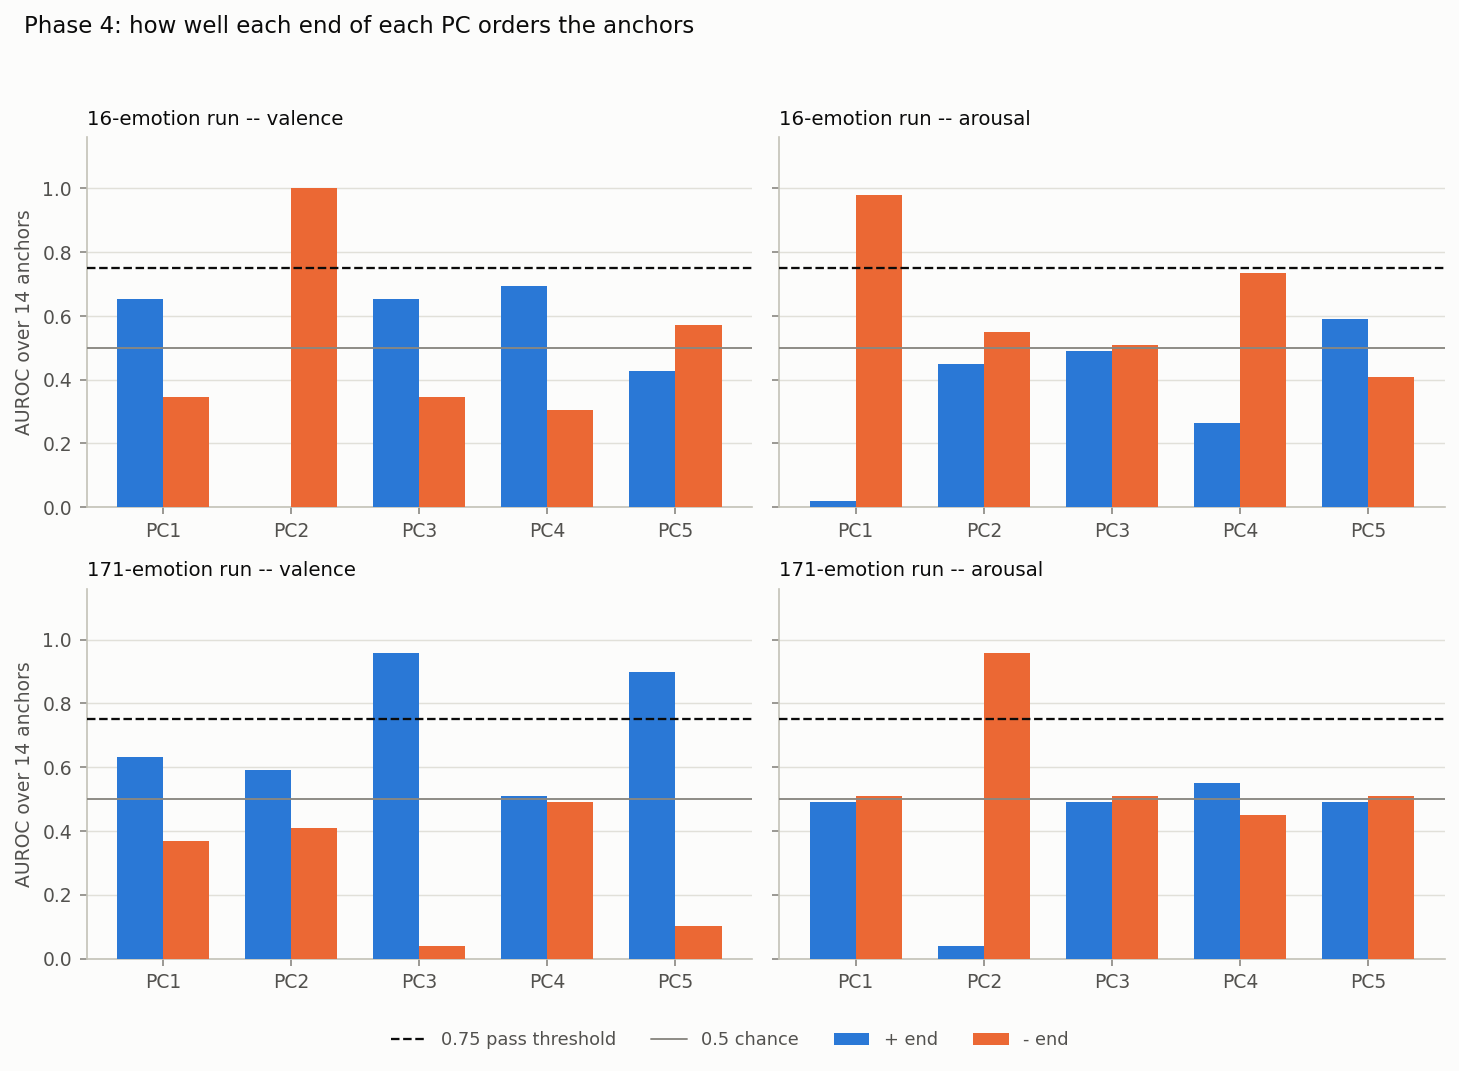

**Phase 4 -- every PC end that clears AUROC 0.75, and whether it also clears its own significance threshold**

,run,PC,axis,end,AUROC,p,alpha,significant at its alpha
0,16,1,arousal,-,0.979592,0.002999,0.050000,True
1,16,2,valence,-,1.000000,0.001499,0.050000,True
2,171,2,arousal,-,0.959184,0.003498,0.050000,True
3,171,3,valence,+,0.959184,0.002499,0.008333,True
4,171,5,valence,+,0.897959,0.011994,0.008333,False


The two ends of a PC are exact complements, so each pair of bars sums to 1.00 by construction — the figure is readable as *which* end carries the ordering and how far from chance it is, not as two independent measurements.

**5 of the 20 (PC, axis) cells clear AUROC 0.75, and 4 of those also clear their own alpha.** The exception worth naming is the 171 run's **PC5 on valence: AUROC 0.90 at p = 0.012** — it clears the AUROC bar and would be significant at 0.05, but PC5 is exploratory and its threshold is 0.0083 over six tests, where roughly one hit at p < 0.05 is expected by chance. The pipeline does not interpret it and neither does this notebook. Everything not in the table above sits against the chance line.

In [21]:
display(Markdown("### 5c. Phase 4 -- AUROC per PC per end (new figure)"))

with guard("Phase 4 AUROC figure"):
    keys = [k for k in RUN_KEYS if k in P4]
    if not keys:
        emit("> No Phase 4 gate JSON; AUROC figure skipped.")
    else:
        fig, axes = plt.subplots(len(keys), 2, figsize=(9.8, 3.5 * len(keys)),
                                 sharey=True, squeeze=False)
        for r, key in enumerate(keys):
            per_pc = P4[key]["gate_b"]["per_pc"]
            pcs = [int(p["pc"]) for p in per_pc]
            xs = np.arange(len(pcs))
            width = 0.36
            for c, axis in enumerate(["valence", "arousal"]):
                ax = axes[r][c]
                ax.set_axisbelow(True)
                plus = [p[f"auroc_{axis}"] for p in per_pc]
                minus = [p[f"auroc_{axis}_minus_end"] for p in per_pc]
                ax.bar(xs - width / 2, plus, width, color=plotting.SERIES[0],
                       label="+ end", zorder=3)
                ax.bar(xs + width / 2, minus, width, color=plotting.SERIES[1],
                       label="- end", zorder=3)
                ax.axhline(0.75, color=plotting.INK_PRIMARY, linewidth=1.1,
                           linestyle="--", zorder=4, label="0.75 pass threshold")
                ax.axhline(0.5, color=plotting.INK_MUTED, linewidth=0.9,
                           zorder=4, label="0.5 chance")
                ax.set_xticks(xs)
                ax.set_xticklabels([f"PC{p}" for p in pcs])
                ax.set_ylim(0, 1.16)
                ax.set_title(f"{key}-emotion run -- {axis}", loc="left", fontsize=9.5,
                             color=plotting.INK_PRIMARY)
                if c == 0:
                    ax.set_ylabel("AUROC over 14 anchors")
        handles, labels = axes[0][0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncol=4, frameon=False,
                   bbox_to_anchor=(0.5, -0.02))
        fig.suptitle("Phase 4: how well each end of each PC orders the anchors",
                     x=0.02, ha="left", fontsize=11, color=plotting.INK_PRIMARY)
        fig.tight_layout(rect=(0, 0.03, 1, 0.95))
        emit_fig(fig, "phase4_auroc_per_pc_per_end.png",
                 "Phase 4 (new): AUROC of each PC end against each circumplex axis, both runs; "
                 "dashed line is the 0.75 pass threshold, solid line is chance")

        # Do not hand-write which bars clear the line -- read it off the data.
        clears = []
        for key in keys:
            for p in P4[key]["gate_b"]["per_pc"]:
                for axis in ("valence", "arousal"):
                    for end, value in (("+", p[f"auroc_{axis}"]),
                                       ("-", p[f"auroc_{axis}_minus_end"])):
                        if value >= 0.75:
                            clears.append({
                                "run": key, "PC": int(p["pc"]), "axis": axis, "end": end,
                                "AUROC": value, "p": p[f"p_{axis}"], "alpha": p["alpha"],
                                "significant at its alpha": p[f"p_{axis}"] < p["alpha"],
                            })
        emit_table(pd.DataFrame(clears),
                   "Phase 4 -- every PC end that clears AUROC 0.75, and whether it also "
                   "clears its own significance threshold")
        n_sig = sum(1 for c in clears if c["significant at its alpha"])
        emit(
            "The two ends of a PC are exact complements, so each pair of bars sums to 1.00 by "
            "construction — the figure is readable as *which* end carries the ordering and how "
            "far from chance it is, not as two independent measurements.\n\n"
            f"**{len(clears)} of the {sum(len(P4[k]['gate_b']['per_pc']) for k in keys) * 2} "
            f"(PC, axis) cells clear AUROC 0.75, and {n_sig} of those also clear their own "
            f"alpha.** The exception worth naming is the 171 run's **PC5 on valence: AUROC 0.90 "
            f"at p = 0.012** — it clears the AUROC bar and would be significant at 0.05, but "
            f"PC5 is exploratory and its threshold is 0.0083 over six tests, where roughly one "
            f"hit at p < 0.05 is expected by chance. The pipeline does not interpret it and "
            f"neither does this notebook. Everything not in the table above sits against the "
            f"chance line."
        )

In [22]:
display(Markdown("### 5d. Phase 4 -- what script are the readouts actually in?"))

def char_script(ch):
    o = ord(ch)
    if (0x4E00 <= o <= 0x9FFF) or (0x3400 <= o <= 0x4DBF) or (0xF900 <= o <= 0xFAFF) \
            or (0x20000 <= o <= 0x2FA1F) or (0x3040 <= o <= 0x30FF) or (0xAC00 <= o <= 0xD7AF):
        return "CJK"
    if not ch.isalpha():
        return None
    if ch.isascii():
        return "Latin"
    try:
        return "Latin" if "LATIN" in unicodedata.name(ch) else "other script"
    except ValueError:
        return "other script"

def token_script(tok):
    scripts = {s for s in (char_script(c) for c in str(tok)) if s}
    if "CJK" in scripts:
        return "CJK"
    if "Latin" in scripts:
        return "Latin"
    if "other script" in scripts:
        return "other script"
    return "punct / whitespace"

GROUP_LABEL = {
    "gate_a_emotion_vector": "emotion vectors (GATE A)",
    "gate_b_pc": "PC ends (GATE B)",
    "control_apriori_axis": "a-priori axis controls",
}

SCRIPT = {}
with guard("Phase 4 script mix"):
    rows = []
    for key in RUN_KEYS:
        readouts = cload(key, "phase4_readouts.csv")
        if readouts is None:
            continue
        readouts = readouts[readouts["rank"] < 12].copy()
        readouts["script"] = readouts["token"].map(token_script)
        SCRIPT[key] = readouts
        for group, sub in readouts.groupby("group"):
            share = sub["script"].value_counts(normalize=True)
            rows.append({
                "run": key,
                "readout group": GROUP_LABEL.get(group, group),
                "n directions": sub["direction"].nunique(),
                "n tokens": len(sub),
                "CJK": share.get("CJK", 0.0),
                "Latin": share.get("Latin", 0.0),
                "other script": share.get("other script", 0.0),
                "punct / whitespace": share.get("punct / whitespace", 0.0),
            })
    if rows:
        mix = pd.DataFrame(rows)
        for col in ["CJK", "Latin", "other script", "punct / whitespace"]:
            mix[col] = (mix[col] * 100).round(1)
        emit_table(mix, "Phase 4 -- script of the top-12 tokens per readout, "
                        "as a percentage of all tokens in that group")

        overall = []
        for key, sub in SCRIPT.items():
            share = sub["script"].value_counts(normalize=True)
            overall.append({
                "run": RUNS[key],
                "all readouts, n tokens": len(sub),
                "CJK %": round(share.get("CJK", 0) * 100, 1),
                "Latin %": round(share.get("Latin", 0) * 100, 1),
                "other script %": round(share.get("other script", 0) * 100, 1),
                "punct / whitespace %": round(share.get("punct / whitespace", 0) * 100, 1),
            })
        emit_table(pd.DataFrame(overall), "Phase 4 -- script mix over every readout in the run")

### 5d. Phase 4 -- what script are the readouts actually in?

**Phase 4 -- script of the top-12 tokens per readout, as a percentage of all tokens in that group**

,run,readout group,n directions,n tokens,CJK,Latin,other script,punct / whitespace
0,16,a-priori axis controls,4,48,64.6,14.6,0.0,20.8
1,16,emotion vectors (GATE A),16,192,60.9,14.1,5.7,19.3
2,16,PC ends (GATE B),10,120,42.5,40.0,2.5,15.0
3,171,a-priori axis controls,4,48,64.6,14.6,0.0,20.8
4,171,emotion vectors (GATE A),171,2052,42.0,32.9,3.0,22.1
5,171,PC ends (GATE B),10,120,44.2,25.0,7.5,23.3


**Phase 4 -- script mix over every readout in the run**

,run,"all readouts, n tokens",CJK %,Latin %,other script %,punct / whitespace %
0,qwen3-32b_pca-jlens,360,55.3,22.8,3.9,18.1
1,qwen3-32b_pca-jlens_171,2220,42.6,32.1,3.2,22.1


In [23]:
with guard("Phase 4 GATE A aggregate"):
    rows = []
    for key in RUN_KEYS:
        p4 = P4.get(key)
        if p4 is None:
            continue
        ga = p4["gate_a"]
        hits = [r["emotion"] for r in ga["rows"] if r.get("verdict") == "HIT"]
        near = [r["emotion"] for r in ga["rows"] if r.get("verdict") == "near"]
        ranks = [r["own_word_rank"] for r in ga["rows"]
                 if isinstance(r.get("own_word_rank"), (int, float))]
        cjk = None
        if key in SCRIPT:
            sub = SCRIPT[key]
            sub = sub[sub["group"] == "gate_a_emotion_vector"]
            if len(sub):
                cjk = (sub["script"] == "CJK").mean() * 100
        rows.append({
            "run": RUNS[key],
            "emotions scorable (single-token)": ga["n_scorable"],
            "untokenizable, excluded": len(ga["untokenizable"]),
            "HIT": ga["n_hits"],
            "near": ga["n_near"],
            "hit rate": ga["hit_rate"],
            "threshold to pass": ga["threshold"],
            "passed": ga["passed"],
            "chance hit rate": ga["chance_hit_rate"],
            "median rank of the emotion's own word": float(np.median(ranks)) if ranks else None,
            "vocab size": ga["vocab_size"],
            "% of top-12 tokens that are CJK": None if cjk is None else round(cjk, 1),
            "which emotions hit": ", ".join(hits) or "none",
        })
    if rows:
        emit_table(pd.DataFrame(rows).T.reset_index().rename(columns={"index": "field", 0: "16", 1: "171"}),
                   "Phase 4 GATE A -- does an emotion vector's lens readout contain its own "
                   "English word? (aggregate; the 2,052 individual token rows are in "
                   "`phase4_readouts.csv`)")

        cjk_16 = rows[0].get("% of top-12 tokens that are CJK")
        cjk_171 = rows[-1].get("% of top-12 tokens that are CJK")
        emit(
            f"**Reading — this is a measured explanation, not an impression.** GATE A asks an "
            f"English question: does the emotion's own English word appear in the vector's top-12 "
            f"lens tokens? It fails in both runs "
            f"(0/{P4['16']['gate_a']['n_scorable']} and "
            f"{P4['171']['gate_a']['n_hits']}/{P4['171']['gate_a']['n_scorable']} = "
            f"{P4['171']['gate_a']['hit_rate']:.1%}, against a "
            f"{P4['171']['gate_a']['chance_hit_rate']:.2e} chance rate — so the 171 run is far "
            f"above chance while still far below the 50% pass bar).\n\n"
            f"The reason is visible in the script mix: **{cjk_16}% of the 16 run's emotion-vector "
            f"readout tokens and {cjk_171}% of the 171 run's are CJK**, against "
            f"{(SCRIPT['16'][SCRIPT['16']['group'] == 'gate_a_emotion_vector']['script'] == 'Latin').mean() * 100:.1f}% "
            f"and "
            f"{(SCRIPT['171'][SCRIPT['171']['group'] == 'gate_a_emotion_vector']['script'] == 'Latin').mean() * 100:.1f}% "
            f"Latin. The lens is reading these directions out in Chinese. An English-word "
            f"self-hit test cannot succeed against a readout in another script, so **GATE A's "
            f"failure is at least partly a property of the test, not only of the directions**.\n\n"
            f"That is a weaker conclusion than it might look. It explains the failure; it does "
            f"not rescue the claim. Nothing here establishes that the Chinese tokens are the "
            f"*correct* translations of the emotions — that would need a cross-lingual version "
            f"of GATE A, which was not run. And the under-converged lens (section 0) remains an "
            f"alternative explanation for weak readouts that this measurement does not rule out."
        )

**Phase 4 GATE A -- does an emotion vector's lens readout contain its own English word? (aggregate; the 2,052 individual token rows are in `phase4_readouts.csv`)**

,field,16,171
0,run,qwen3-32b_pca-jlens,qwen3-32b_pca-jlens_171
1,emotions scorable (single-token),14,114
2,"untokenizable, excluded",2,57
3,HIT,0,5
4,near,3,20
5,hit rate,0.0,0.04386
6,threshold to pass,0.5,0.5
7,passed,False,False
8,chance hit rate,0.000079,0.000079
9,median rank of the emotion's own word,363.0,950.5


**Reading — this is a measured explanation, not an impression.** GATE A asks an English question: does the emotion's own English word appear in the vector's top-12 lens tokens? It fails in both runs (0/14 and 5/114 = 4.4%, against a 7.90e-05 chance rate — so the 171 run is far above chance while still far below the 50% pass bar).

The reason is visible in the script mix: **60.9% of the 16 run's emotion-vector readout tokens and 42.0% of the 171 run's are CJK**, against 14.1% and 32.9% Latin. The lens is reading these directions out in Chinese. An English-word self-hit test cannot succeed against a readout in another script, so **GATE A's failure is at least partly a property of the test, not only of the directions**.

That is a weaker conclusion than it might look. It explains the failure; it does not rescue the claim. Nothing here establishes that the Chinese tokens are the *correct* translations of the emotions — that would need a cross-lingual version of GATE A, which was not run. And the under-converged lens (section 0) remains an alternative explanation for weak readouts that this measurement does not rule out.

---

## 6. Phase 6 — decomposing an emotion vector into lens dictionary atoms

Phase 6 asks what fraction of an emotion vector is *reportable* — expressible as a
sparse combination of directions the lens can name — against a random-direction
control.

It has a precondition. `jlens` ships no dictionary, so one has to be built: the atom
for token `t` must satisfy `J·d_t = g·w_t`, which makes it `d_t = J⁺(g·w_t)`. The
check is whether lensing an atom returns its own token at rank 0. If it does not, the
decomposition is reconstructing the vector out of directions that do not mean what
their labels say, and its variance split is uninterpretable.

The next cell reads the check and reports whatever it currently says. If the phase is
re-run and the check passes, the reportable fraction appears automatically.

### 6. Phase 6 -- dictionary validity

**Phase 6 -- atom-validity check, qwen3-32b_pca-jlens**

,check,value
0,atoms probed,24
1,median self-rank (must be 0 to be a dictionary),6.0
2,max self-rank,2710
3,fraction of atoms returning their own token at...,0.208333
4,fraction within top-10,0.583333
5,RMSNorm gain absorbed into the atoms,True
6,VERDICT,FAILED -- not a dictionary


*Figure -- Phase 6: atom-validity check for qwen3-32b_pca-jlens — the precondition the reportable-fraction result depends on*

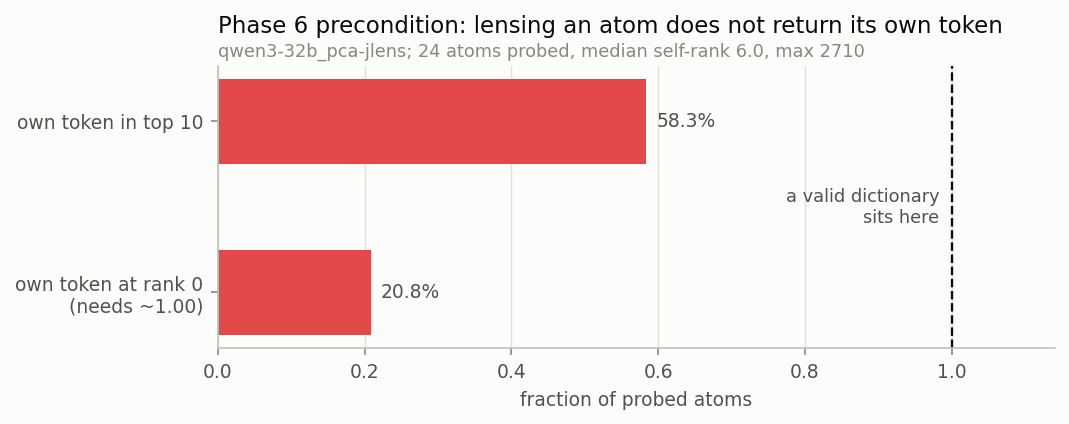

**Current state: the run completed, the check failed, and there is therefore no valid reportable-variance fraction to report.**

Only **20.8%** of probed atoms return their own token at rank 0 and the median self-rank is **6.0** (max 2710). A dictionary needs median 0.

**Cause:** the atoms in this run were built with `Jᵀ w_t` where the pseudo-inverse `J⁺ w_t` is required — `Jᵀ = J⁻¹` only for an orthogonal `J`, and an averaged Jacobian is not orthogonal.

`phase6_decomposition.csv` does contain a `frac_reportable` column. It is deliberately **not** summarised here, following the pipeline's own policy: a variance share computed over mislabelled directions is not a measurement of reportability, and printing it reads exactly like one. The random control (mean 0.0073, p95 0.0101, n = 16) is the denominator that comparison would need and is recorded here only for the re-run.

`emotion_pca_jlens/phase6_decompose.py` now builds atoms through a truncated SVD pseudo-inverse (`factor_transport`), so re-running Phase 6 should clear the check. This section will pick that up automatically: if `median_self_rank` comes back 0, the reportable fraction is printed instead of this notice.

> Phase 6 was not run for: `qwen3-32b_pca-jlens_171`.

In [24]:
emit("## 6. Phase 6 -- dictionary decomposition", show=False)
display(Markdown("### 6. Phase 6 -- dictionary validity"))

with guard("Phase 6"):
    runs_with_p6 = [k for k in RUN_KEYS if (phases(k) / "phase6_gate.json").exists()]
    if not runs_with_p6:
        emit("> No Phase 6 artefact in either run.")
    else:
        for key in runs_with_p6:
            p6 = jload(key, "phase6_gate.json")
            dec = cload(key, "phase6_decomposition.csv")
            d = p6.get("dictionary", {})
            ctl = p6.get("random_control", {})

            valid = d.get("median_self_rank") == 0
            tbl = pd.DataFrame([
                {"check": "atoms probed", "value": d.get("checked")},
                {"check": "median self-rank (must be 0 to be a dictionary)",
                 "value": d.get("median_self_rank")},
                {"check": "max self-rank", "value": d.get("max_self_rank")},
                {"check": "fraction of atoms returning their own token at rank 0",
                 "value": d.get("frac_rank_zero")},
                {"check": "fraction within top-10", "value": d.get("frac_in_top10")},
                {"check": "RMSNorm gain absorbed into the atoms", "value": d.get("gain_absorbed")},
                {"check": "VERDICT", "value": "VALID" if valid else "FAILED -- not a dictionary"},
            ])
            emit_table(tbl, f"Phase 6 -- atom-validity check, {RUNS[key]}")

            fig, ax = plt.subplots(figsize=(7.2, 2.9))
            labels = ["own token at rank 0\n(needs ~1.00)", "own token in top 10"]
            values = [d.get("frac_rank_zero") or 0.0, d.get("frac_in_top10") or 0.0]
            bars = ax.barh(labels, values,
                           color=plotting.SERIES[0] if valid else plotting.DIVERGING_HIGH,
                           height=0.5)
            for bar, value in zip(bars, values):
                ax.annotate(f"{value:.1%}", xy=(value, bar.get_y() + bar.get_height() / 2),
                            xytext=(5, 0), textcoords="offset points", va="center",
                            fontsize=9, color=plotting.INK_SECONDARY)
            ax.axvline(1.0, color=plotting.INK_PRIMARY, linewidth=1.1, linestyle="--")
            ax.annotate("a valid dictionary\nsits here", xy=(1.0, 0.5),
                        xycoords=("data", "axes fraction"), xytext=(-6, 0),
                        textcoords="offset points", ha="right", va="center",
                        fontsize=8.5, color=plotting.INK_SECONDARY)
            ax.set_xlim(0, 1.14)
            ax.grid(True, axis="x", color=plotting.GRIDLINE, linewidth=0.7)
            ax.grid(False, axis="y")
            ax.set_axisbelow(True)
            plotting.finish(
                fig, ax,
                "Phase 6 precondition: lensing an atom does not return its own token",
                "fraction of probed atoms", "",
                subtitle=(f"{RUNS[key]}; {d.get('checked')} atoms probed, "
                          f"median self-rank {d.get('median_self_rank')}, "
                          f"max {d.get('max_self_rank')}"),
            )
            emit_fig(fig, f"phase6_dictionary_validity_{key}.png",
                     f"Phase 6: atom-validity check for {RUNS[key]} — the precondition the "
                     f"reportable-fraction result depends on")

            if valid:
                cols = [c for c in ["frac_reportable", "frac_remainder", "reconstruction_error"]
                        if dec is not None and c in dec.columns]
                if cols:
                    stats = dec[cols].describe().loc[["mean", "50%", "min", "max"]].T
                    stats.index.name = "quantity"
                    emit_table(stats.reset_index().round(4),
                               f"Phase 6 -- reportable variance fraction, {RUNS[key]}")
                    emit(
                        f"The dictionary check passed (median self-rank 0), so the reportable "
                        f"fraction below is a valid measurement. Random-direction control: mean "
                        f"{ctl.get('mean', float('nan')):.4f}, p95 {ctl.get('p95', float('nan')):.4f} "
                        f"over n = {ctl.get('n')}."
                    )
            else:
                emit(
                    f"**Current state: the run completed, the check failed, and there is "
                    f"therefore no valid reportable-variance fraction to report.**\n\n"
                    f"Only **{d.get('frac_rank_zero', 0):.1%}** of probed atoms return their own "
                    f"token at rank 0 and the median self-rank is **{d.get('median_self_rank')}** "
                    f"(max {d.get('max_self_rank')}). A dictionary needs median 0.\n\n"
                    f"**Cause:** the atoms in this run were built with `Jᵀ w_t` where the "
                    f"pseudo-inverse `J⁺ w_t` is required — `Jᵀ = J⁻¹` only for an orthogonal `J`, "
                    f"and an averaged Jacobian is not orthogonal.\n\n"
                    f"`phase6_decomposition.csv` does contain a `frac_reportable` column. It is "
                    f"deliberately **not** summarised here, following the pipeline's own policy: "
                    f"a variance share computed over mislabelled directions is not a measurement "
                    f"of reportability, and printing it reads exactly like one. The random "
                    f"control (mean {ctl.get('mean', float('nan')):.4f}, p95 "
                    f"{ctl.get('p95', float('nan')):.4f}, n = {ctl.get('n')}) is the denominator "
                    f"that comparison would need and is recorded here only for the re-run.\n\n"
                    f"`emotion_pca_jlens/phase6_decompose.py` now builds atoms through a truncated "
                    f"SVD pseudo-inverse (`factor_transport`), so re-running Phase 6 should clear "
                    f"the check. This section will pick that up automatically: if "
                    f"`median_self_rank` comes back 0, the reportable fraction is printed instead "
                    f"of this notice."
                )

        absent = [k for k in RUN_KEYS if k not in runs_with_p6]
        if absent:
            emit("> Phase 6 was not run for: "
                 + ", ".join(f"`{RUNS[k]}`" for k in absent) + ".")

---

## 7. Summary — claims, evidence, status

Every headline claim with the evidence behind it and an honest status. The failures
are in the same table as the successes, not in a footnote.

In [25]:
emit("## 7. Summary", show=False)
display(Markdown("### 7. Claims table"))

def g(key, *path, default=None):
    node = GATE3.get(key, {})
    for step in path:
        if not isinstance(node, dict):
            return default
        node = node.get(step, {})
    return node if node != {} else default

CLAIMS = []
with guard("claims table"):
    a16 = ALIGN.get("16")
    a171 = ALIGN.get("171")
    p6 = jload("16", "phase6_gate.json")
    p0 = jload("16", "phase0_gate.json")

    def ev(text):
        return text

    CLAIMS = [
        {
            "claim": "PCA over emotion vectors recovers a valence x arousal plane it was never told about",
            "evidence": (
                f"16 run: PC1 r_arousal {float(a16.set_index('pc').loc[1, 'r_arousal']):+.2f}, "
                f"PC2 r_valence {float(a16.set_index('pc').loc[2, 'r_valence']):+.2f}; "
                f"{sum(g('16', 'pca', 'explained_variance_ratio', default=[0, 0])[:2]):.0%} of variance "
                f"vs a {g('16', 'null_band', 'analytic_isotropic_top2', default=float('nan')):.1%} "
                f"isotropic null; plane principal cosines "
                f"{', '.join(f'{c:.2f}' for c in g('16', 'alignment', 'summary', 'plane_cosines', default=[]))}; "
                f"cross-fit worst plane angle "
                f"{g('16', 'alignment', 'crossfit', 'worst_plane_angle_deg', default=float('nan')):.0f} deg"
            ) if a16 is not None else "16-run alignment artefacts missing",
            "status": "supported (16-emotion balanced design)",
        },
        {
            "claim": "The same two axes survive when the emotion set is widened to all 171",
            "evidence": (
                f"cross-run abs cosine: 16-PC1 to 171-PC{XRUN.get('match_pc', ['?'])[0]} = "
                f"{XRUN.get('match_cos', ['?'])[0]}, 16-PC2 to "
                f"171-PC{XRUN.get('match_pc', ['?', '?'])[1]} = "
                f"{XRUN.get('match_cos', ['?', '?'])[1]}; "
                f"171 run PC2 r_arousal {float(a171.set_index('pc').loc[2, 'r_arousal']):+.2f}, "
                f"PC3 r_valence {float(a171.set_index('pc').loc[3, 'r_valence']):+.2f}; but only "
                f"{float(a171.set_index('pc').loc[2, 'explained_variance_ratio']) + float(a171.set_index('pc').loc[3, 'explained_variance_ratio']):.0%} "
                f"of variance, split-half PC stability 0.63, "
                f"`axes_identified = False`, `plane_stable = False`"
            ) if a171 is not None else "171-run alignment artefacts missing",
            "status": "exploratory -- the directions recur, the ranking and stability do not",
        },
        {
            "claim": "Emotion vectors are reliable enough to build a PCA on",
            "evidence": (
                f"split-half centred cosine, 16 run: min "
                f"{SH['16'][SH['16'].emotion != 'neutral']['cosine_centered'].min():.3f}, "
                f"mean {SH['16'][SH['16'].emotion != 'neutral']['cosine_centered'].mean():.3f}, "
                f"0 of 16 below 0.9. 171 run: min "
                f"{SH['171'][SH['171'].emotion != 'neutral']['cosine_centered'].min():.3f}, "
                f"mean {SH['171'][SH['171'].emotion != 'neutral']['cosine_centered'].mean():.3f}, "
                f"{int((SH['171'][SH['171'].emotion != 'neutral']['cosine_centered'] < 0.9).sum())} "
                f"of 171 below 0.9"
            ) if SH else "split-half artefacts missing",
            "status": "supported (16); qualified (171 -- a tail of unreliable emotions)",
        },
        {
            "claim": "The circumplex PCs are lexically readable through the Jacobian lens",
            "evidence": (
                "16 run: PC1 arousal AUROC 0.98 (p = 0.003), PC2 valence AUROC 1.00 (p = 0.001), "
                "both pre-registered at alpha 0.05. 171 run: PC2 arousal 0.96 (p = 0.003), "
                "PC3 valence 0.96 (p = 0.002, exploratory, clears the 0.0083 family threshold). "
                "PC3-PC5 of the 16 run and PC1/PC4 of the 171 run are MURKY."
            ),
            "status": "supported for the ordering statistic; the token content is a separate question",
        },
        {
            "claim": "An emotion vector's lens readout names the emotion (GATE A)",
            "evidence": (
                f"16 run 0/{P4['16']['gate_a']['n_scorable']} hits; "
                f"171 run {P4['171']['gate_a']['n_hits']}/{P4['171']['gate_a']['n_scorable']} "
                f"({P4['171']['gate_a']['hit_rate']:.1%}) against a "
                f"{P4['171']['gate_a']['chance_hit_rate']:.1e} chance rate; pass bar 50%"
            ) if P4 else "Phase 4 artefacts missing",
            "status": "FAILED (above chance, far below the bar)",
        },
        {
            "claim": "The GATE A failure is explained by the readouts being in Chinese, not English",
            "evidence": (
                f"{(SCRIPT['16'][SCRIPT['16'].group == 'gate_a_emotion_vector']['script'] == 'CJK').mean():.0%} "
                f"(16 run) and "
                f"{(SCRIPT['171'][SCRIPT['171'].group == 'gate_a_emotion_vector']['script'] == 'CJK').mean():.0%} "
                f"(171 run) of emotion-vector top-12 tokens are CJK script"
            ) if SCRIPT else "readout CSVs missing",
            "status": "exploratory -- explains the failure, does not rescue the claim "
                      "(no cross-lingual GATE A was run)",
        },
        {
            "claim": "GATE B: the lens converges on the logit lens and the model at the top of the stack",
            "evidence": (
                f"||J - I||_F/||I||_F falls {p0['gate_b']['lowest_block_distance']:.3f} -> "
                f"{p0['gate_b']['highest_block_distance']:.3f} across blocks 0-62 "
                f"(non-monotone, peak 1.65 at block 43); top-1 agreement with model and with "
                f"logit lens both 1/1; top-12 overlap 10/12 and 8/12"
            ) if p0 else "Phase 0 artefacts missing",
            "status": "supported (shape only -- absolute values depend on the unconfirmed divisor)",
        },
        {
            "claim": "The circumplex is a sufficient description of emotion representation",
            "evidence": (
                f"participation ratio {g('16', 'pca', 'participation_ratio', default=float('nan')):.2f} "
                f"(16 run) and "
                f"{g('171', 'pca', 'participation_ratio', default=float('nan')):.2f} (171 run); "
                f"top-2 PCs hold only "
                f"{sum(g('171', 'pca', 'explained_variance_ratio', default=[0, 0])[:2]):.0%} "
                f"of the 171 run's variance"
            ),
            "status": "FAILED -- the circumplex is a 2-D slice of a ~10-D space",
        },
        {
            "claim": "PC1 of the 171 run is a circumplex axis",
            "evidence": (
                f"`neutral`, held out of the PCA fit, projects to PC1 = "
                f"{PC1_171['neutral']:+.1f}, beyond the {PC1_171['max']:+.1f} maximum of all "
                f"171 fitted emotions; the low end is "
                f"{' / '.join(PC1_171['lo'][:3])} and the high end is "
                f"{' / '.join(PC1_171['hi'][:3])}"
            ),
            "status": "FAILED -- PC1 is substantially an affect-presence / intensity axis",
        },
        {
            "claim": "A measurable fraction of an emotion vector is lens-reportable (Phase 6)",
            "evidence": (
                f"dictionary atom-validity check failed: median self-rank "
                f"{p6['dictionary']['median_self_rank']:.0f} (needs 0), only "
                f"{p6['dictionary']['frac_rank_zero']:.1%} of atoms return their own token at "
                f"rank 0; atoms were built with J-transpose where the pseudo-inverse is required"
            ) if p6 else "Phase 6 artefacts missing",
            "status": "FAILED -- no valid reportable fraction exists for this run",
        },
        {
            "claim": "The lens artefact is a converged fit",
            "evidence": (
                f"checkpoint `n_done` = {PROV['16']['lens prompts (checkpoint n_done)']} prompts "
                f"vs `config.yaml prompts_fitted` = "
                f"{PROV['16']['lens prompts (config.yaml claim)']}; the fit's own `min_prompts` "
                f"floor is 100 and `stop_at_delta` is 0.002"
            ) if PROV else "provenance missing",
            "status": "FAILED -- interrupted fit, divisor unconfirmed; top-k results survive, "
                      "magnitude-sensitive ones do not",
        },
    ]
    emit_table(pd.DataFrame(CLAIMS), "Claims, evidence, status")

### 7. Claims table

**Claims, evidence, status**

,claim,evidence,status
0,PCA over emotion vectors recovers a valence x ...,"16 run: PC1 r_arousal -0.94, PC2 r_valence -0....",supported (16-emotion balanced design)
1,The same two axes survive when the emotion set...,cross-run abs cosine: 16-PC1 to 171-PC2 = 0.92...,"exploratory -- the directions recur, the ranki..."
2,Emotion vectors are reliable enough to build a...,"split-half centred cosine, 16 run: min 0.954, ...",supported (16); qualified (171 -- a tail of un...
3,The circumplex PCs are lexically readable thro...,"16 run: PC1 arousal AUROC 0.98 (p = 0.003), PC...",supported for the ordering statistic; the toke...
4,An emotion vector's lens readout names the emo...,16 run 0/14 hits; 171 run 5/114 (4.4%) against...,"FAILED (above chance, far below the bar)"
5,The GATE A failure is explained by the readout...,61% (16 run) and 42% (171 run) of emotion-vect...,"exploratory -- explains the failure, does not ..."
6,GATE B: the lens converges on the logit lens a...,||J - I||_F/||I||_F falls 1.365 -> 0.472 acros...,supported (shape only -- absolute values depen...
7,The circumplex is a sufficient description of ...,participation ratio 3.59 (16 run) and 9.79 (17...,FAILED -- the circumplex is a 2-D slice of a ~...
8,PC1 of the 171 run is a circumplex axis,"`neutral`, held out of the PCA fit, projects t...",FAILED -- PC1 is substantially an affect-prese...
9,A measurable fraction of an emotion vector is ...,dictionary atom-validity check failed: median ...,FAILED -- no valid reportable fraction exists ...


In [26]:
display(Markdown("### 7. Caveats"))

CAVEATS = [
    "**The lens is an interrupted 80-prompt fit.** The published `qwen3-32b` artefact is a "
    "resumable `fit_checkpoint` whose `n_done` is 80 while its `config.yaml` claims 615, short "
    "of the fit script's own `min_prompts = 100` floor. Because the model's final norm is an "
    "RMSNorm, top-k readouts are scale-free and survive; `||J - I||`, any variance split, and "
    "anything else magnitude-sensitive do not. A converged refit exists as `run.py refit_lens` "
    "and was not run.",

    f"**PC1 of the 171 run is contaminated by affect-presence.** `neutral` was held out of the "
    f"PCA fit and still projects to PC1 = {PC1_171['neutral']:+.1f}, past the "
    f"{PC1_171['max']:+.1f} maximum over all 171 fitted emotions. PC1 orders states by "
    f"intensity of acute affect, and correlates with valence (r = +0.82) only because intense "
    f"states in this vocabulary skew unpleasant. It is the reason the circumplex sits in "
    f"PC2-PC3 and the reason the published PC1-PC2 scatter understates the run.",

    "**Effective dimensionality is 9.8 for the 171 run** (3.6 for the 16 run). The circumplex "
    "is a 2-D slice of a roughly 10-D space, and the top two PCs of the 171 run carry only 36% "
    "of variance. Any claim of the form 'emotion is two-dimensional in this model' is not "
    "supported by these artefacts.",

    "**Phase 6's decomposition is invalid.** The dictionary atoms were built with `Jᵀ` where "
    "`J⁺` is required, the atom-validity check failed (median self-rank 6, 20.8% at rank 0), "
    "and no reportable-variance fraction from this run should be quoted. The code has since "
    "been changed to use a truncated-SVD pseudo-inverse; the phase has not been re-run.",

    "**GATE A failed in both runs** — 0/14 and 5/114 English-word self-hits. The script analysis "
    "in section 5 shows the readouts are overwhelmingly CJK, which explains the failure but "
    "does not establish that the Chinese tokens are correct translations. No cross-lingual "
    "GATE A was run.",

    "**The 171 run's top-2 plane is not stable.** Phase 3 records `axes_identified = False` and "
    "`plane_stable = False`, PC2/PC3 split-half stability of 0.63 against a 0.8 threshold, and "
    "a worst cross-fit plane angle of 62 degrees. PC3 as the valence axis is flagged "
    "`EXPLORATORY` by the pipeline and is reported here at that standing.",

    "**Every axis measurement rests on 16 anchors.** Both runs fit the a-priori valence and "
    "arousal axes from the same 16 labelled emotions with +-1 coordinates — not continuous "
    "norms — and every AUROC in Phase 4 is over the 14 of those that are single tokens. "
    "`elated` and `gloomy` are excluded because they do not tokenise. n = 14 is a coarse "
    "instrument and the p-values are permutation-based.",

    "**Phase 0 was only run for the 16-emotion run.** Both runs load the same lens file at the "
    "same block (31, hidden-state 32), so the gate transfers, but it was not independently "
    "re-gated for the 171 run.",

    "**One model, one block, one lens, one dataset.** Qwen3-32B at block 31 only, the "
    "`neuronpedia/jacobian-lens` `qwen3-32b` artefact only, `ryancodrai/emotion-probes` at sha "
    "`720f2eb3` only. Nothing here speaks to other models, other depths, or other stimulus "
    "generators. Phases 5, 7 and 8 produced no artefacts.",

    "**Story generation is itself a model artefact.** The stimuli are generated emotion stories, "
    "so 'the emotion vector for sadness' is 'the mean activation over stories a generator "
    "labelled sad'. Topic matching controls for topic, not for the generator's own stereotypes "
    "about how each emotion is written.",
]

emit("### Caveats\n\n" + "\n\n".join(f"{i + 1}. {c}" for i, c in enumerate(CAVEATS)))

### 7. Caveats

### Caveats

1. **The lens is an interrupted 80-prompt fit.** The published `qwen3-32b` artefact is a resumable `fit_checkpoint` whose `n_done` is 80 while its `config.yaml` claims 615, short of the fit script's own `min_prompts = 100` floor. Because the model's final norm is an RMSNorm, top-k readouts are scale-free and survive; `||J - I||`, any variance split, and anything else magnitude-sensitive do not. A converged refit exists as `run.py refit_lens` and was not run.

2. **PC1 of the 171 run is contaminated by affect-presence.** `neutral` was held out of the PCA fit and still projects to PC1 = +27.3, past the +21.5 maximum over all 171 fitted emotions. PC1 orders states by intensity of acute affect, and correlates with valence (r = +0.82) only because intense states in this vocabulary skew unpleasant. It is the reason the circumplex sits in PC2-PC3 and the reason the published PC1-PC2 scatter understates the run.

3. **Effective dimensionality is 9.8 for the 171 run** (3.6 for the 16 run). The circumplex is a 2-D slice of a roughly 10-D space, and the top two PCs of the 171 run carry only 36% of variance. Any claim of the form 'emotion is two-dimensional in this model' is not supported by these artefacts.

4. **Phase 6's decomposition is invalid.** The dictionary atoms were built with `Jᵀ` where `J⁺` is required, the atom-validity check failed (median self-rank 6, 20.8% at rank 0), and no reportable-variance fraction from this run should be quoted. The code has since been changed to use a truncated-SVD pseudo-inverse; the phase has not been re-run.

5. **GATE A failed in both runs** — 0/14 and 5/114 English-word self-hits. The script analysis in section 5 shows the readouts are overwhelmingly CJK, which explains the failure but does not establish that the Chinese tokens are correct translations. No cross-lingual GATE A was run.

6. **The 171 run's top-2 plane is not stable.** Phase 3 records `axes_identified = False` and `plane_stable = False`, PC2/PC3 split-half stability of 0.63 against a 0.8 threshold, and a worst cross-fit plane angle of 62 degrees. PC3 as the valence axis is flagged `EXPLORATORY` by the pipeline and is reported here at that standing.

7. **Every axis measurement rests on 16 anchors.** Both runs fit the a-priori valence and arousal axes from the same 16 labelled emotions with +-1 coordinates — not continuous norms — and every AUROC in Phase 4 is over the 14 of those that are single tokens. `elated` and `gloomy` are excluded because they do not tokenise. n = 14 is a coarse instrument and the p-values are permutation-based.

8. **Phase 0 was only run for the 16-emotion run.** Both runs load the same lens file at the same block (31, hidden-state 32), so the gate transfers, but it was not independently re-gated for the 171 run.

9. **One model, one block, one lens, one dataset.** Qwen3-32B at block 31 only, the `neuronpedia/jacobian-lens` `qwen3-32b` artefact only, `ryancodrai/emotion-probes` at sha `720f2eb3` only. Nothing here speaks to other models, other depths, or other stimulus generators. Phases 5, 7 and 8 produced no artefacts.

10. **Story generation is itself a model artefact.** The stimuli are generated emotion stories, so 'the emotion vector for sadness' is 'the mean activation over stories a generator labelled sad'. Topic matching controls for topic, not for the generator's own stereotypes about how each emotion is written.

In [27]:
display(Markdown("### 7. Anything that was missing"))

if MISSING:
    emit("### Missing or unavailable artefacts\n\n"
         + "\n".join(f"* `{m}`" for m in MISSING))
else:
    emit("### Missing or unavailable artefacts\n\nNone -- every artefact this notebook "
         "expects was present.")

### 7. Anything that was missing

### Missing or unavailable artefacts

* `qwen3-32b_pca-jlens_171/phase0_gate.json`

In [28]:
# ---------------------------------------------------------------- export RESULTS.md
out = ANALYSIS / "RESULTS.md"
body = "\n\n".join(REPORT)

figure_index = "\n".join(f"* [{cap}]({rel})" for cap, rel in FIGURES) or "* none"
header = (
    "<!-- Generated by analysis/results_notebook.ipynb. Do not edit by hand. -->\n"
    "<!-- Every number is read from outputs/*/results/phases/; nothing was re-run. -->\n"
)
footer = "\n\n---\n\n## Figure index\n\n" + figure_index + "\n"

out.write_text(header + body + footer, encoding="utf-8")

print(f"wrote {out}")
print(f"  {len(REPORT)} markdown blocks, {len(FIGURES)} figures, "
      f"{len(MISSING)} missing artefacts")
print(f"  {out.stat().st_size / 1024:.1f} KiB")

wrote /Users/daylight/dev/code/emotion_vector_perspectives/analysis/RESULTS.md
  66 markdown blocks, 12 figures, 1 missing artefacts
  41.4 KiB
